# ⚡ Electric Vehicle Market Analysis

**Abstract:** This study presents a comprehensive empirical analysis of the global electric vehicle (EV) market using a structured dataset of 3,022 vehicle configurations spanning 53 manufacturers and model years 2015–2025. Employing a rigorous pipeline of data cleaning, feature engineering, exploratory data analysis, statistical hypothesis testing, unsupervised clustering, and supervised regression modelling, this paper identifies key determinants of EV pricing, range, efficiency, and 2024 sales performance. Findings reveal that battery chemistry is the primary driver of energy efficiency, price segment does not significantly predict unit sales, and the premium ($80K–$110K) tier represents the highest untapped volume opportunity. A K-Means clustering analysis uncovers five distinct market archetypes, while an Ordinary Least Squares regression model explains approximately 40% of price variance. Actionable recommendations are provided for product strategy, portfolio positioning, and R&D investment.

---

**Keywords:** Electric Vehicles, Market Analysis, Machine Learning, Clustering, Regression, Battery Technology, Autonomous Driving

---

**Analysis Pipeline:**
```
Data Loading → Quality Audit → Cleaning → Feature Engineering → EDA (12 sections)
→ Outlier Analysis → PHEV/BEV Segmentation → Colour & Warranty Analysis
→ Multivariate Analysis → K-Means Clustering → Statistical Testing (ANOVA/t-test)
→ Predictive Modelling (OLS + Random Forest) → Strategic Insights → Export
```

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

# ── Statistical & modelling libraries ─────────────────────────────────────────
from scipy import stats
from scipy.stats import f_oneway, ttest_ind, shapiro, levene
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore')

# ── Visual style ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

ACCENT = '#3b82d4'
RED    = '#e74c3c'
GREEN  = '#27ae60'

print('Libraries loaded ✓')

Libraries loaded ✓


---
## 1. Data Loading & Initial Inspection

In [2]:
df_raw = pd.read_csv('electric_vehicles_dataset.csv')

print(f'Shape : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Memory: {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB')
display(df_raw.head(3))
display(df_raw.dtypes.rename('dtype').to_frame())

Shape : 3,022 rows × 17 columns
Memory: 1320.8 KB


,Vehicle_ID,Manufacturer,Model,Year,Battery_Type,Battery_Capacity_kWh,Range_km,Charging_Type,Charge_Time_hr,Price_USD,Color,Country_of_Manufacture,Autonomous_Level,CO2_Emissions_g_per_km,Safety_Rating,Units_Sold_2024,Warranty_Years
0,1,Acura,ZDX (with GM Ultium),2015,Lithium-titanate,55.8,214,CHAdeMO,9.0,111203.94,Matte White,UK,0.0,NaN,5.0,19726,3
1,2,Lamborghini,Revuelto (PHEV),2025,Lithium-titanate,90.8,212,Vehicle-to-Home (V2H),7.3,127131.65,White,Netherlands,2.0,0.0,4.0,3349,3
2,3,NIO,ET7,2020,Calcium-ion,64.7,235,Level 2 Charging,8.9,94347.37,Beige,UK,5.0,0.0,5.0,6300,5


,dtype
Vehicle_ID,int64
Manufacturer,str
Model,str
Year,int64
Battery_Type,str
Battery_Capacity_kWh,float64
Range_km,int64
Charging_Type,str
Charge_Time_hr,float64
Price_USD,float64


In [3]:
# Missing-value audit
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
mv_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
mv_report = mv_report[mv_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('Columns with missing values:')
display(mv_report)

print(f"\nDuplicates: {df_raw.duplicated().sum()}")

Columns with missing values:


,Missing Count,Missing %
CO2_Emissions_g_per_km,592,19.59
Autonomous_Level,442,14.63
Safety_Rating,337,11.15



Duplicates: 0


In [4]:
# Statistical summary
display(df_raw.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Vehicle_ID,3022.0,NaN,NaN,NaN,1511.5,872.520582,1.0,756.25,1511.5,2266.75,3022.0
Manufacturer,3022,53,Ferrari,78,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,3022,181,Nevera,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,3022.0,NaN,NaN,NaN,2020.019523,3.132083,2015.0,2017.0,2020.0,2023.0,2025.0
Battery_Type,3022,15,Lithium-titanate,233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Battery_Capacity_kWh,3022.0,NaN,NaN,NaN,84.314692,37.210461,20.0,52.425,83.6,115.8,150.0
Range_km,3022.0,NaN,NaN,NaN,349.901059,145.406139,100.0,222.0,347.0,478.0,600.0
Charging_Type,3022,16,Mobile Charging,206,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Charge_Time_hr,3022.0,NaN,NaN,NaN,6.212045,3.350597,0.5,3.3,6.2,9.1,12.0
Price_USD,3022.0,NaN,NaN,NaN,90611.90676,34654.533838,30014.46,61257.39,90929.705,120199.8425,149978.53


---
## 2. Data Cleaning

In [5]:
df = df_raw.copy()

# ── 2.1 Handle missing values ─────────────────────────────────────────────────
# CO2_Emissions_g_per_km: missing ~19.6% — many BEVs legitimately have 0 emissions.
# Impute with 0 for rows where no ICE backup (proxy: not PHEV in model name),
# else fill with column median.
is_phev = df['Model'].str.contains('PHEV', case=False, na=False)
df.loc[df['CO2_Emissions_g_per_km'].isna() & ~is_phev, 'CO2_Emissions_g_per_km'] = 0.0
df['CO2_Emissions_g_per_km'] = df['CO2_Emissions_g_per_km'].fillna(df['CO2_Emissions_g_per_km'].median())

# Autonomous_Level: ordinal — fill with median (mode is fine too, median is safer)
df['Autonomous_Level'] = df['Autonomous_Level'].fillna(df['Autonomous_Level'].median())

# Safety_Rating: fill with median
df['Safety_Rating'] = df['Safety_Rating'].fillna(df['Safety_Rating'].median())

# ── 2.2 Type casts ────────────────────────────────────────────────────────────
df['Autonomous_Level'] = df['Autonomous_Level'].astype(int)
df['Year'] = df['Year'].astype(int)

# ── 2.3 Standardise string columns ────────────────────────────────────────────
for col in ['Manufacturer', 'Battery_Type', 'Charging_Type', 'Country_of_Manufacture', 'Color']:
    df[col] = df[col].str.strip().str.title()

# ── 2.4 Drop Vehicle_ID (surrogate key, no analytical value) ──────────────────
df.drop(columns=['Vehicle_ID'], inplace=True)

print('Cleaning complete.')
print(f'Remaining nulls: {df.isnull().sum().sum()}')
display(df.head(3))

Cleaning complete.
Remaining nulls: 0


,Manufacturer,Model,Year,Battery_Type,Battery_Capacity_kWh,Range_km,Charging_Type,Charge_Time_hr,Price_USD,Color,Country_of_Manufacture,Autonomous_Level,CO2_Emissions_g_per_km,Safety_Rating,Units_Sold_2024,Warranty_Years
0,Acura,ZDX (with GM Ultium),2015,Lithium-Titanate,55.8,214,Chademo,9.0,111203.94,Matte White,Uk,0,0.0,5.0,19726,3
1,Lamborghini,Revuelto (PHEV),2025,Lithium-Titanate,90.8,212,Vehicle-To-Home (V2H),7.3,127131.65,White,Netherlands,2,0.0,4.0,3349,3
2,Nio,ET7,2020,Calcium-Ion,64.7,235,Level 2 Charging,8.9,94347.37,Beige,Uk,5,0.0,5.0,6300,5


---
## 3. Feature Engineering

In [6]:
# ── 3.1 High-Range Segment (binary flag) ──────────────────────────────────────
# Threshold: 400 km (industry convention for long-range BEV capability)
HIGH_RANGE_THRESHOLD = 400
df['High_Range'] = (df['Range_km'] >= HIGH_RANGE_THRESHOLD).astype(int)
print(f"High-range vehicles (≥{HIGH_RANGE_THRESHOLD} km): {df['High_Range'].sum():,} "
      f"({df['High_Range'].mean()*100:.1f}%)")

# ── 3.2 Price Segment ─────────────────────────────────────────────────────────
price_bins   = [0, 50_000, 80_000, 110_000, float('inf')]
price_labels = ['Budget (<$50K)', 'Mid ($50K–$80K)', 'Premium ($80K–$110K)', 'Luxury (>$110K)']
df['Price_Segment'] = pd.cut(df['Price_USD'], bins=price_bins, labels=price_labels, right=False)
print('\nPrice Segment distribution:')
print(df['Price_Segment'].value_counts().sort_index())

# ── 3.3 Range per kWh (Efficiency metric) ─────────────────────────────────────
df['Range_per_kWh'] = (df['Range_km'] / df['Battery_Capacity_kWh']).round(3)
print(f"\nRange per kWh — mean: {df['Range_per_kWh'].mean():.2f} km/kWh  "
      f"| max: {df['Range_per_kWh'].max():.2f}  | min: {df['Range_per_kWh'].min():.2f}")

# ── 3.4 Price per km of Range (Value-for-range metric) ────────────────────────
df['Price_per_km'] = (df['Price_USD'] / df['Range_km']).round(2)
print(f"Price per km  — mean: ${df['Price_per_km'].mean():.2f}  "
      f"| best: ${df['Price_per_km'].min():.2f}  | worst: ${df['Price_per_km'].max():.2f}")

# ── 3.5 Efficiency Tier ───────────────────────────────────────────────────────
eff_labels = ['Low', 'Medium', 'High', 'Top']
df['Efficiency_Tier'] = pd.qcut(df['Range_per_kWh'], q=4, labels=eff_labels)

# ── 3.6 Revenue proxy ─────────────────────────────────────────────────────────
df['Est_Revenue_2024'] = df['Price_USD'] * df['Units_Sold_2024']

# ── 3.7 Vehicle era ───────────────────────────────────────────────────────────
era_bins   = [2014, 2018, 2021, 2025]
era_labels = ['Early (2015-2018)', 'Mid (2019-2021)', 'Recent (2022-2025)']
df['Era'] = pd.cut(df['Year'], bins=era_bins, labels=era_labels)

print('\nAll engineered features created ✓')
display(df[['Manufacturer','Model','Year','Range_km','Price_USD',
            'High_Range','Price_Segment','Range_per_kWh','Price_per_km',
            'Efficiency_Tier','Est_Revenue_2024','Era']].head())

High-range vehicles (≥400 km): 1,211 (40.1%)

Price Segment distribution:
Price_Segment
Budget (<$50K)           502
Mid ($50K–$80K)          731
Premium ($80K–$110K)     766
Luxury (>$110K)         1023
Name: count, dtype: int64

Range per kWh — mean: 5.44 km/kWh  | max: 28.82  | min: 0.70
Price per km  — mean: $326.00  | best: $51.93  | worst: $1407.75

All engineered features created ✓


,Manufacturer,Model,Year,Range_km,Price_USD,High_Range,Price_Segment,Range_per_kWh,Price_per_km,Efficiency_Tier,Est_Revenue_2024,Era
0,Acura,ZDX (with GM Ultium),2015,214,111203.94,0,Luxury (>$110K),3.835,519.64,Medium,2.193609e+09,Early (2015-2018)
1,Lamborghini,Revuelto (PHEV),2025,212,127131.65,0,Luxury (>$110K),2.335,599.68,Low,4.257639e+08,Recent (2022-2025)
2,Nio,ET7,2020,235,94347.37,0,Premium ($80K–$110K),3.632,401.48,Medium,5.943884e+08,Mid (2019-2021)
3,Audi,e-tron,2025,140,75615.15,0,Mid ($50K–$80K),1.162,540.11,Low,1.768638e+08,Recent (2022-2025)
4,Acura,ZDX (with GM Ultium),2023,336,141046.94,0,Luxury (>$110K),6.486,419.78,High,1.482403e+08,Recent (2022-2025)


---
## 4. Exploratory Data Analysis
### 4.1 Univariate Distributions — Core Numeric Features

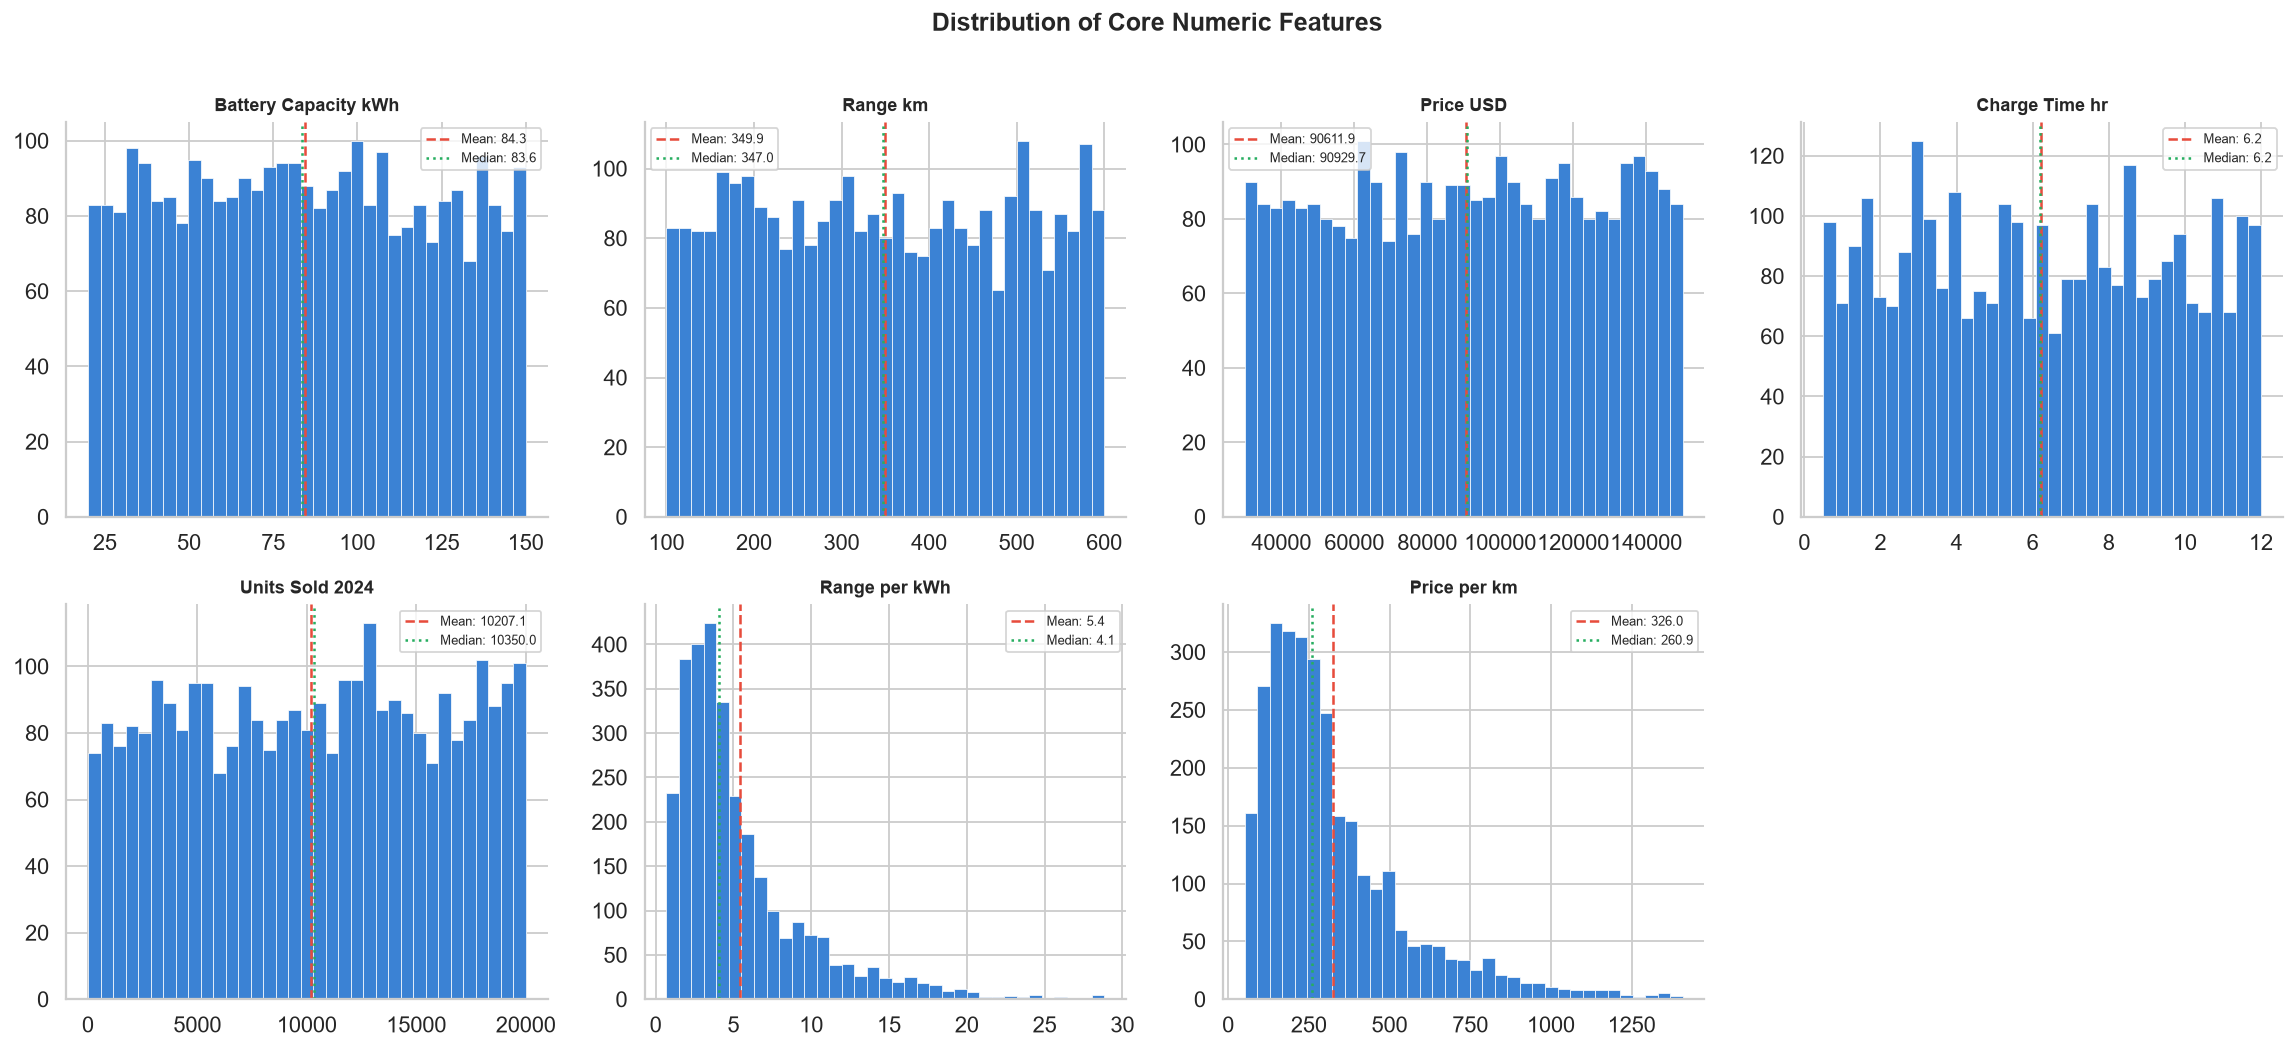

In [7]:
numeric_cols = ['Battery_Capacity_kWh', 'Range_km', 'Price_USD',
                'Charge_Time_hr', 'Units_Sold_2024', 'Range_per_kWh', 'Price_per_km']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=35, color=ACCENT, edgecolor='white', linewidth=0.4)
    ax.axvline(data.mean(),   color=RED,   ls='--', lw=1.4, label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color=GREEN, ls=':',  lw=1.4, label=f'Median: {data.median():.1f}')
    ax.set_title(col.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_xlabel('')

axes[-1].set_visible(False)
fig.suptitle('Distribution of Core Numeric Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Manufacturer Landscape — Top 15 by Units Sold & Revenue

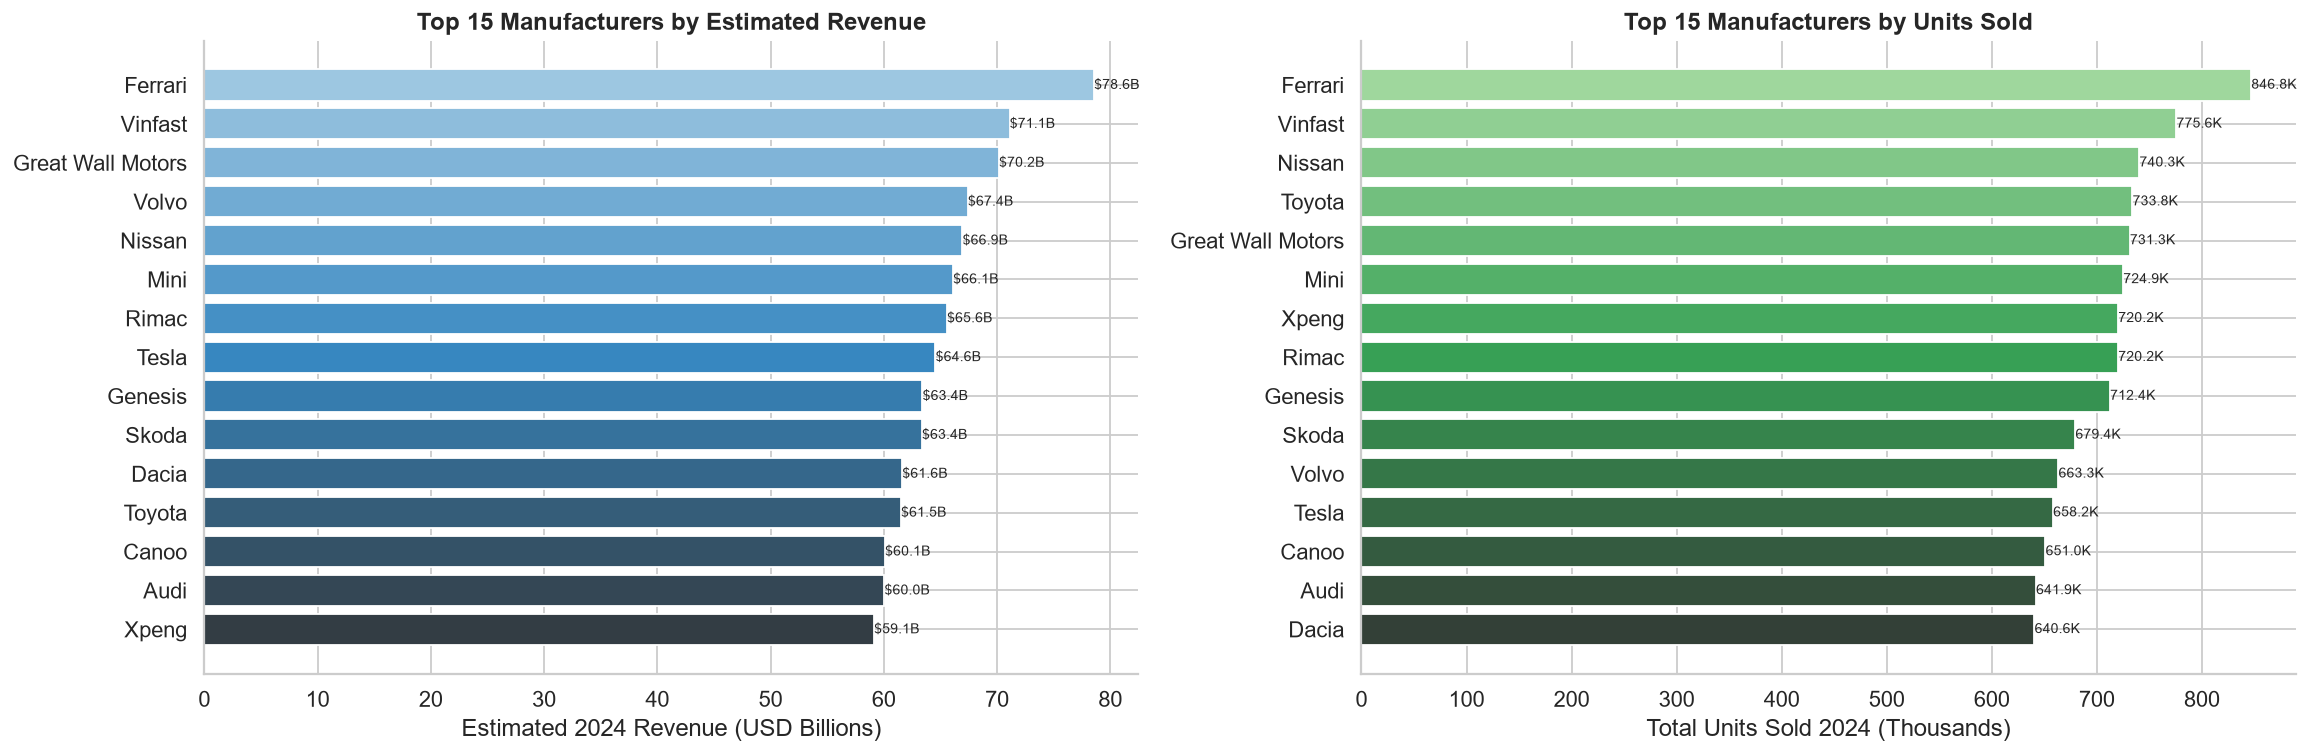


── Top 10 Manufacturers (full stats) ──


,Manufacturer,Models,Avg_Price,Avg_Range,Total_Sales,Total_Revenue,Avg_Efficiency
11,Ferrari,3,"$94,108",337 km,"846,808","$78,556,920,345",5.39 km/kWh
48,Vinfast,5,"$90,797",348 km,"775,647","$71,103,165,939",5.78 km/kWh
17,Great Wall Motors,3,"$95,626",348 km,"731,265","$70,160,684,847",5.25 km/kWh
50,Volvo,4,"$100,310",370 km,"663,311","$67,412,648,157",5.51 km/kWh
34,Nissan,2,"$91,923",347 km,"740,347","$66,941,994,194",5.31 km/kWh
32,Mini,3,"$91,528",327 km,"724,931","$66,106,200,932",5.22 km/kWh
41,Rimac,1,"$89,710",347 km,"720,198","$65,568,691,881",5.15 km/kWh
46,Tesla,6,"$99,844",364 km,"658,215","$64,560,196,428",5.33 km/kWh
15,Genesis,4,"$87,285",336 km,"712,405","$63,408,994,319",5.68 km/kWh
44,Skoda,3,"$92,273",339 km,"679,388","$63,356,383,354",4.63 km/kWh


In [8]:
mfr_stats = (
    df.groupby('Manufacturer')
    .agg(
        Models        = ('Model',           'nunique'),
        Avg_Price     = ('Price_USD',        'mean'),
        Avg_Range     = ('Range_km',         'mean'),
        Total_Sales   = ('Units_Sold_2024',  'sum'),
        Total_Revenue = ('Est_Revenue_2024', 'sum'),
        Avg_Efficiency= ('Range_per_kWh',    'mean'),
    )
    .reset_index()
    .sort_values('Total_Revenue', ascending=False)
)

top15_rev  = mfr_stats.nlargest(15, 'Total_Revenue')
top15_sale = mfr_stats.nlargest(15, 'Total_Sales')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# — Revenue —
bars1 = ax1.barh(top15_rev['Manufacturer'], top15_rev['Total_Revenue'] / 1e9,
                 color=sns.color_palette('Blues_d', 15))
ax1.set_xlabel('Estimated 2024 Revenue (USD Billions)')
ax1.set_title('Top 15 Manufacturers by Estimated Revenue', fontweight='bold')
ax1.invert_yaxis()
for bar, val in zip(bars1, top15_rev['Total_Revenue']):
    ax1.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'${val/1e9:.1f}B', va='center', fontsize=8)

# — Units Sold —
bars2 = ax2.barh(top15_sale['Manufacturer'], top15_sale['Total_Sales'] / 1e3,
                 color=sns.color_palette('Greens_d', 15))
ax2.set_xlabel('Total Units Sold 2024 (Thousands)')
ax2.set_title('Top 15 Manufacturers by Units Sold', fontweight='bold')
ax2.invert_yaxis()
for bar, val in zip(bars2, top15_sale['Total_Sales']):
    ax2.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val/1e3:.1f}K', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print('\n── Top 10 Manufacturers (full stats) ──')
display(mfr_stats.head(10).style.format({
    'Avg_Price':     '${:,.0f}',
    'Avg_Range':     '{:.0f} km',
    'Total_Sales':   '{:,.0f}',
    'Total_Revenue': '${:,.0f}',
    'Avg_Efficiency':'  {:.2f} km/kWh',
}))

### 4.3 Price Segment Analysis

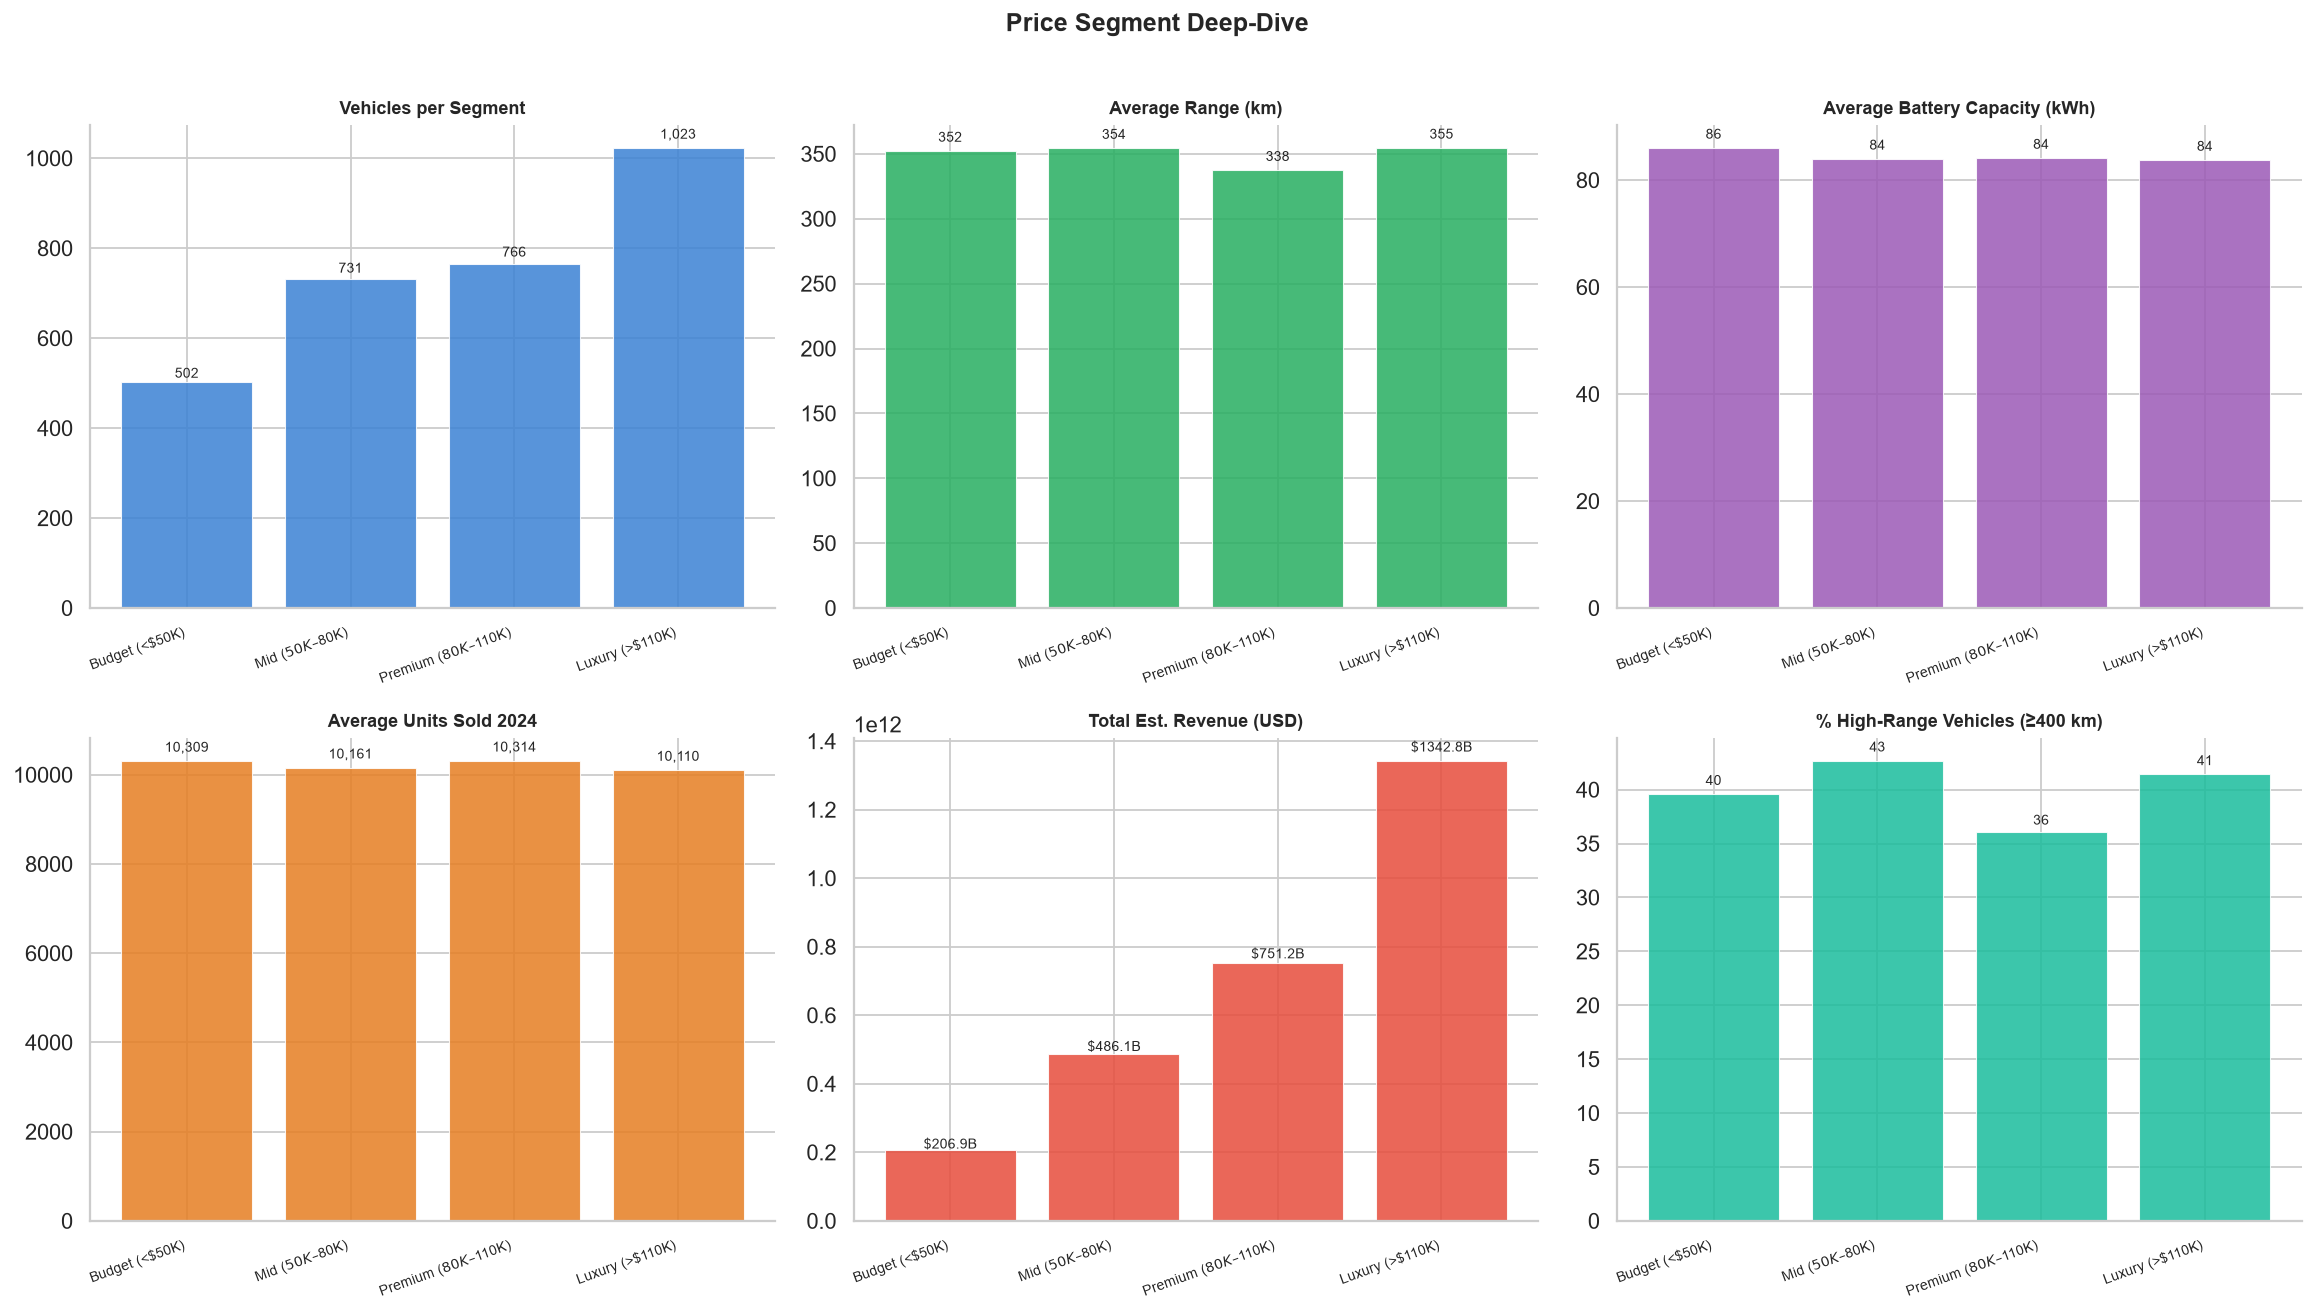

,Price_Segment,Count,Avg_Range,Avg_Battery,Avg_Sales,Total_Revenue,High_Range_Pct,Avg_Efficiency
0,Budget (<$50K),502,352.3 km,86.0 kWh,"10,309","$206,923,470,583",39.6%,5.37 km/kWh
1,Mid ($50K–$80K),731,354.4 km,84.0 kWh,"10,161","$486,070,739,691",42.7%,5.51 km/kWh
2,Premium ($80K–$110K),766,337.8 km,84.2 kWh,"10,314","$751,188,388,554",36.0%,5.26 km/kWh
3,Luxury (>$110K),1023,354.6 km,83.8 kWh,"10,110","$1,342,761,002,016",41.4%,5.58 km/kWh


In [9]:
seg_stats = (
    df.groupby('Price_Segment', observed=True)
    .agg(
        Count         = ('Price_USD',        'count'),
        Avg_Range     = ('Range_km',         'mean'),
        Avg_Battery   = ('Battery_Capacity_kWh','mean'),
        Avg_Sales     = ('Units_Sold_2024',  'mean'),
        Total_Revenue = ('Est_Revenue_2024', 'sum'),
        High_Range_Pct= ('High_Range',       'mean'),
        Avg_Efficiency= ('Range_per_kWh',    'mean'),
    )
    .reset_index()
)
seg_stats['High_Range_Pct'] *= 100

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = [
    ('Count',          'Vehicles per Segment',           ACCENT),
    ('Avg_Range',      'Average Range (km)',              GREEN),
    ('Avg_Battery',    'Average Battery Capacity (kWh)',  '#9b59b6'),
    ('Avg_Sales',      'Average Units Sold 2024',         '#e67e22'),
    ('Total_Revenue',  'Total Est. Revenue (USD)',         RED),
    ('High_Range_Pct', '% High-Range Vehicles (≥400 km)', '#1abc9c'),
]

segs = seg_stats['Price_Segment'].astype(str)

for ax, (col, title, color) in zip(axes.flatten(), metrics):
    bars = ax.bar(segs, seg_stats[col], color=color, alpha=0.85, edgecolor='white', linewidth=0.6)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xticklabels(segs, rotation=20, ha='right', fontsize=8)
    for bar in bars:
        h = bar.get_height()
        fmt = f'${h/1e9:.1f}B' if col == 'Total_Revenue' else f'{h:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2, h * 1.02, fmt,
                ha='center', fontsize=7.5)

fig.suptitle('Price Segment Deep-Dive', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

display(seg_stats.style.format({
    'Avg_Range':      '{:.1f} km',
    'Avg_Battery':    '{:.1f} kWh',
    'Avg_Sales':      '{:,.0f}',
    'Total_Revenue':  '${:,.0f}',
    'High_Range_Pct': '{:.1f}%',
    'Avg_Efficiency': '{:.2f} km/kWh',
}))

### 4.4 Range & Efficiency Analysis

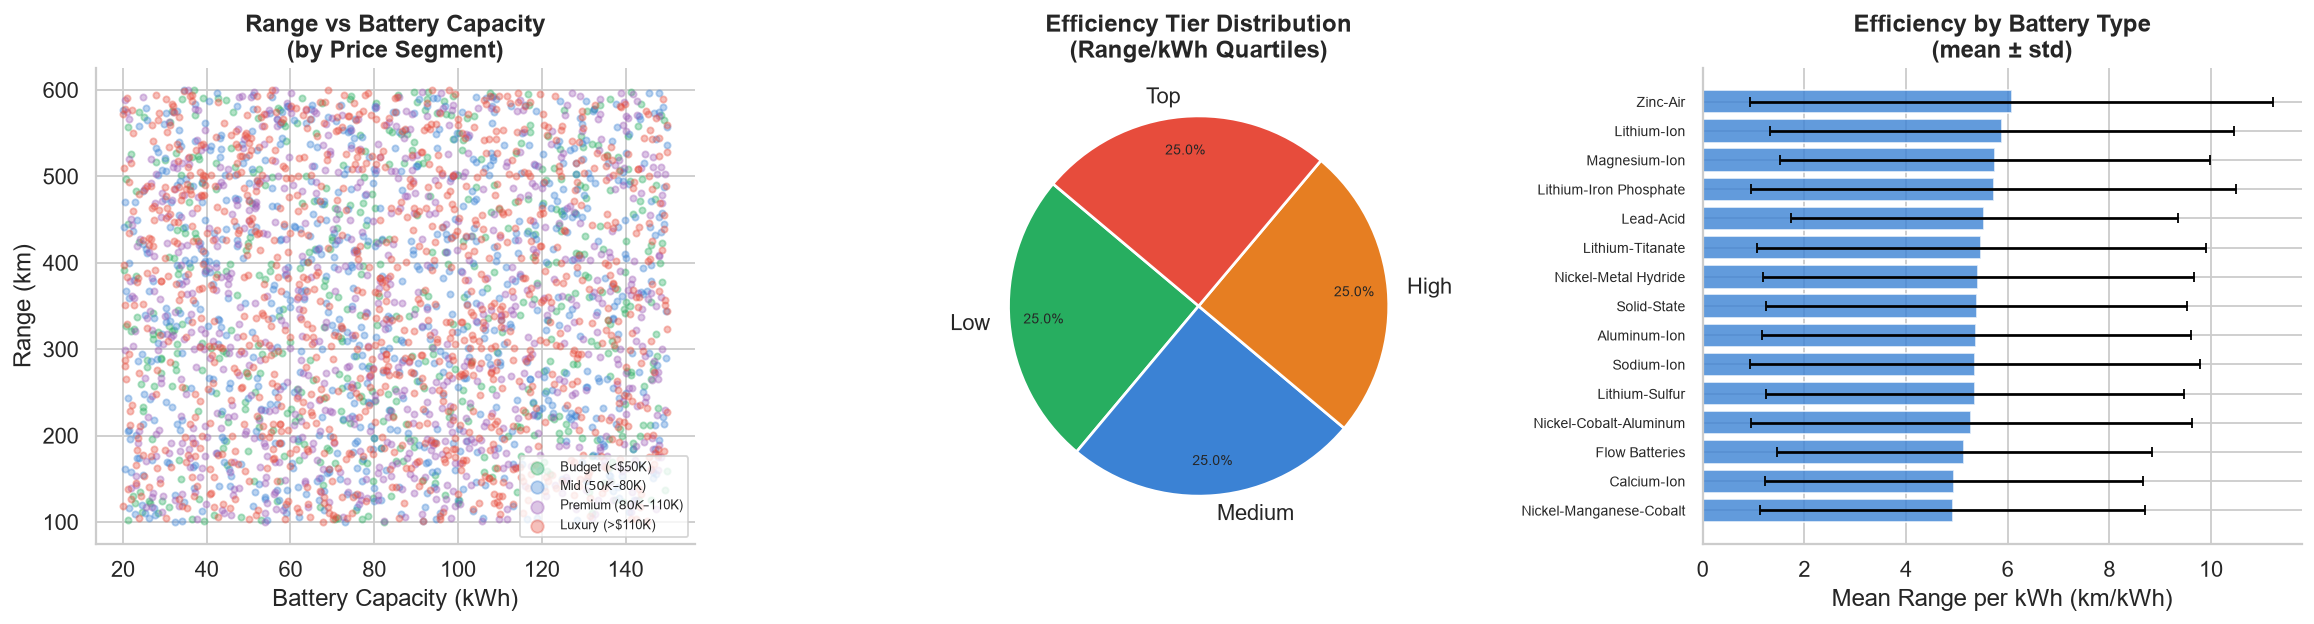

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# — Range vs Battery Capacity coloured by Price Segment —
ax = axes[0]
palette = {'Budget (<$50K)': '#27ae60', 'Mid ($50K–$80K)': '#3b82d4',
           'Premium ($80K–$110K)': '#9b59b6', 'Luxury (>$110K)': '#e74c3c'}
for seg, grp in df.groupby('Price_Segment', observed=True):
    ax.scatter(grp['Battery_Capacity_kWh'], grp['Range_km'],
               label=str(seg), alpha=0.35, s=12, color=palette.get(str(seg), 'grey'))
ax.set_xlabel('Battery Capacity (kWh)')
ax.set_ylabel('Range (km)')
ax.set_title('Range vs Battery Capacity\n(by Price Segment)', fontweight='bold')
ax.legend(fontsize=7, markerscale=2)

# — Efficiency Tier distribution —
ax = axes[1]
eff_counts = df['Efficiency_Tier'].value_counts().sort_index()
colors_eff = [GREEN, ACCENT, '#e67e22', RED]
wedges, texts, autotexts = ax.pie(
    eff_counts.values, labels=eff_counts.index,
    autopct='%1.1f%%', colors=colors_eff,
    startangle=140, pctdistance=0.82,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(8)
ax.set_title('Efficiency Tier Distribution\n(Range/kWh Quartiles)', fontweight='bold')

# — Range per kWh by Battery Type —
ax = axes[2]
batt_eff = (
    df.groupby('Battery_Type')['Range_per_kWh']
    .agg(['mean', 'std'])
    .sort_values('mean', ascending=True)
)
ax.barh(batt_eff.index, batt_eff['mean'], xerr=batt_eff['std'],
        color=ACCENT, alpha=0.8, capsize=3, edgecolor='white')
ax.set_xlabel('Mean Range per kWh (km/kWh)')
ax.set_title('Efficiency by Battery Type\n(mean ± std)', fontweight='bold')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

### 4.5 Technology Deep-Dive — Battery & Charging

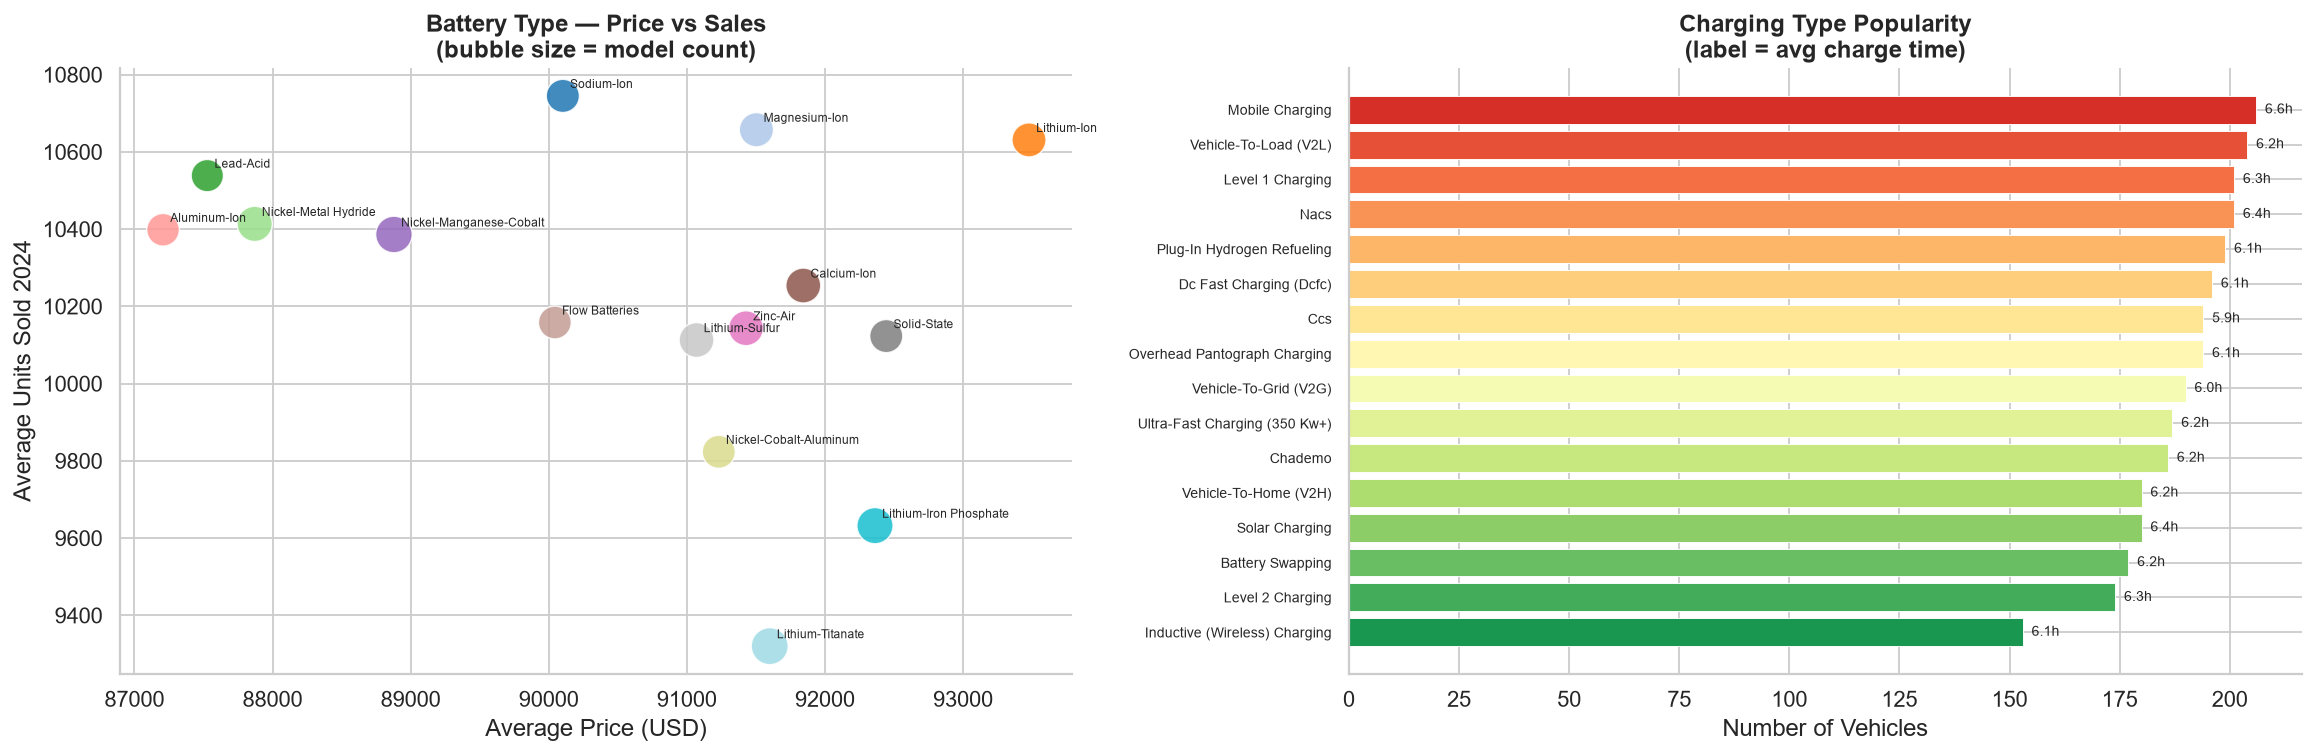

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# — Battery Type: avg sales & avg price —
ax = axes[0]
batt_stats = (
    df.groupby('Battery_Type')
    .agg(Avg_Sales=('Units_Sold_2024','mean'), Avg_Price=('Price_USD','mean'), Count=('Model','count'))
    .sort_values('Avg_Sales', ascending=False)
)
scatter = ax.scatter(batt_stats['Avg_Price'], batt_stats['Avg_Sales'],
                     s=batt_stats['Count'] * 1.8,
                     c=range(len(batt_stats)), cmap='tab20', alpha=0.85, edgecolors='white', lw=0.8)
for idx, row in batt_stats.iterrows():
    ax.annotate(idx, (row['Avg_Price'], row['Avg_Sales']),
                fontsize=6.5, ha='left', va='bottom',
                xytext=(4, 3), textcoords='offset points')
ax.set_xlabel('Average Price (USD)')
ax.set_ylabel('Average Units Sold 2024')
ax.set_title('Battery Type — Price vs Sales\n(bubble size = model count)', fontweight='bold')

# — Charging type popularity & average charge time —
ax = axes[1]
chg_stats = (
    df.groupby('Charging_Type')
    .agg(Count=('Model','count'), Avg_Charge_Time=('Charge_Time_hr','mean'))
    .sort_values('Count', ascending=True)
)
colors_chg = [plt.cm.RdYlGn(v) for v in np.linspace(0.9, 0.1, len(chg_stats))]
bars = ax.barh(chg_stats.index, chg_stats['Count'],
               color=colors_chg, edgecolor='white', linewidth=0.5)
for bar, ct_val in zip(bars, chg_stats['Avg_Charge_Time']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{ct_val:.1f}h', va='center', fontsize=7.5)
ax.set_xlabel('Number of Vehicles')
ax.set_title('Charging Type Popularity\n(label = avg charge time)', fontweight='bold')
ax.tick_params(axis='y', labelsize=7.5)

plt.tight_layout()
plt.show()

### 4.6 Temporal Trends — Model Year Analysis

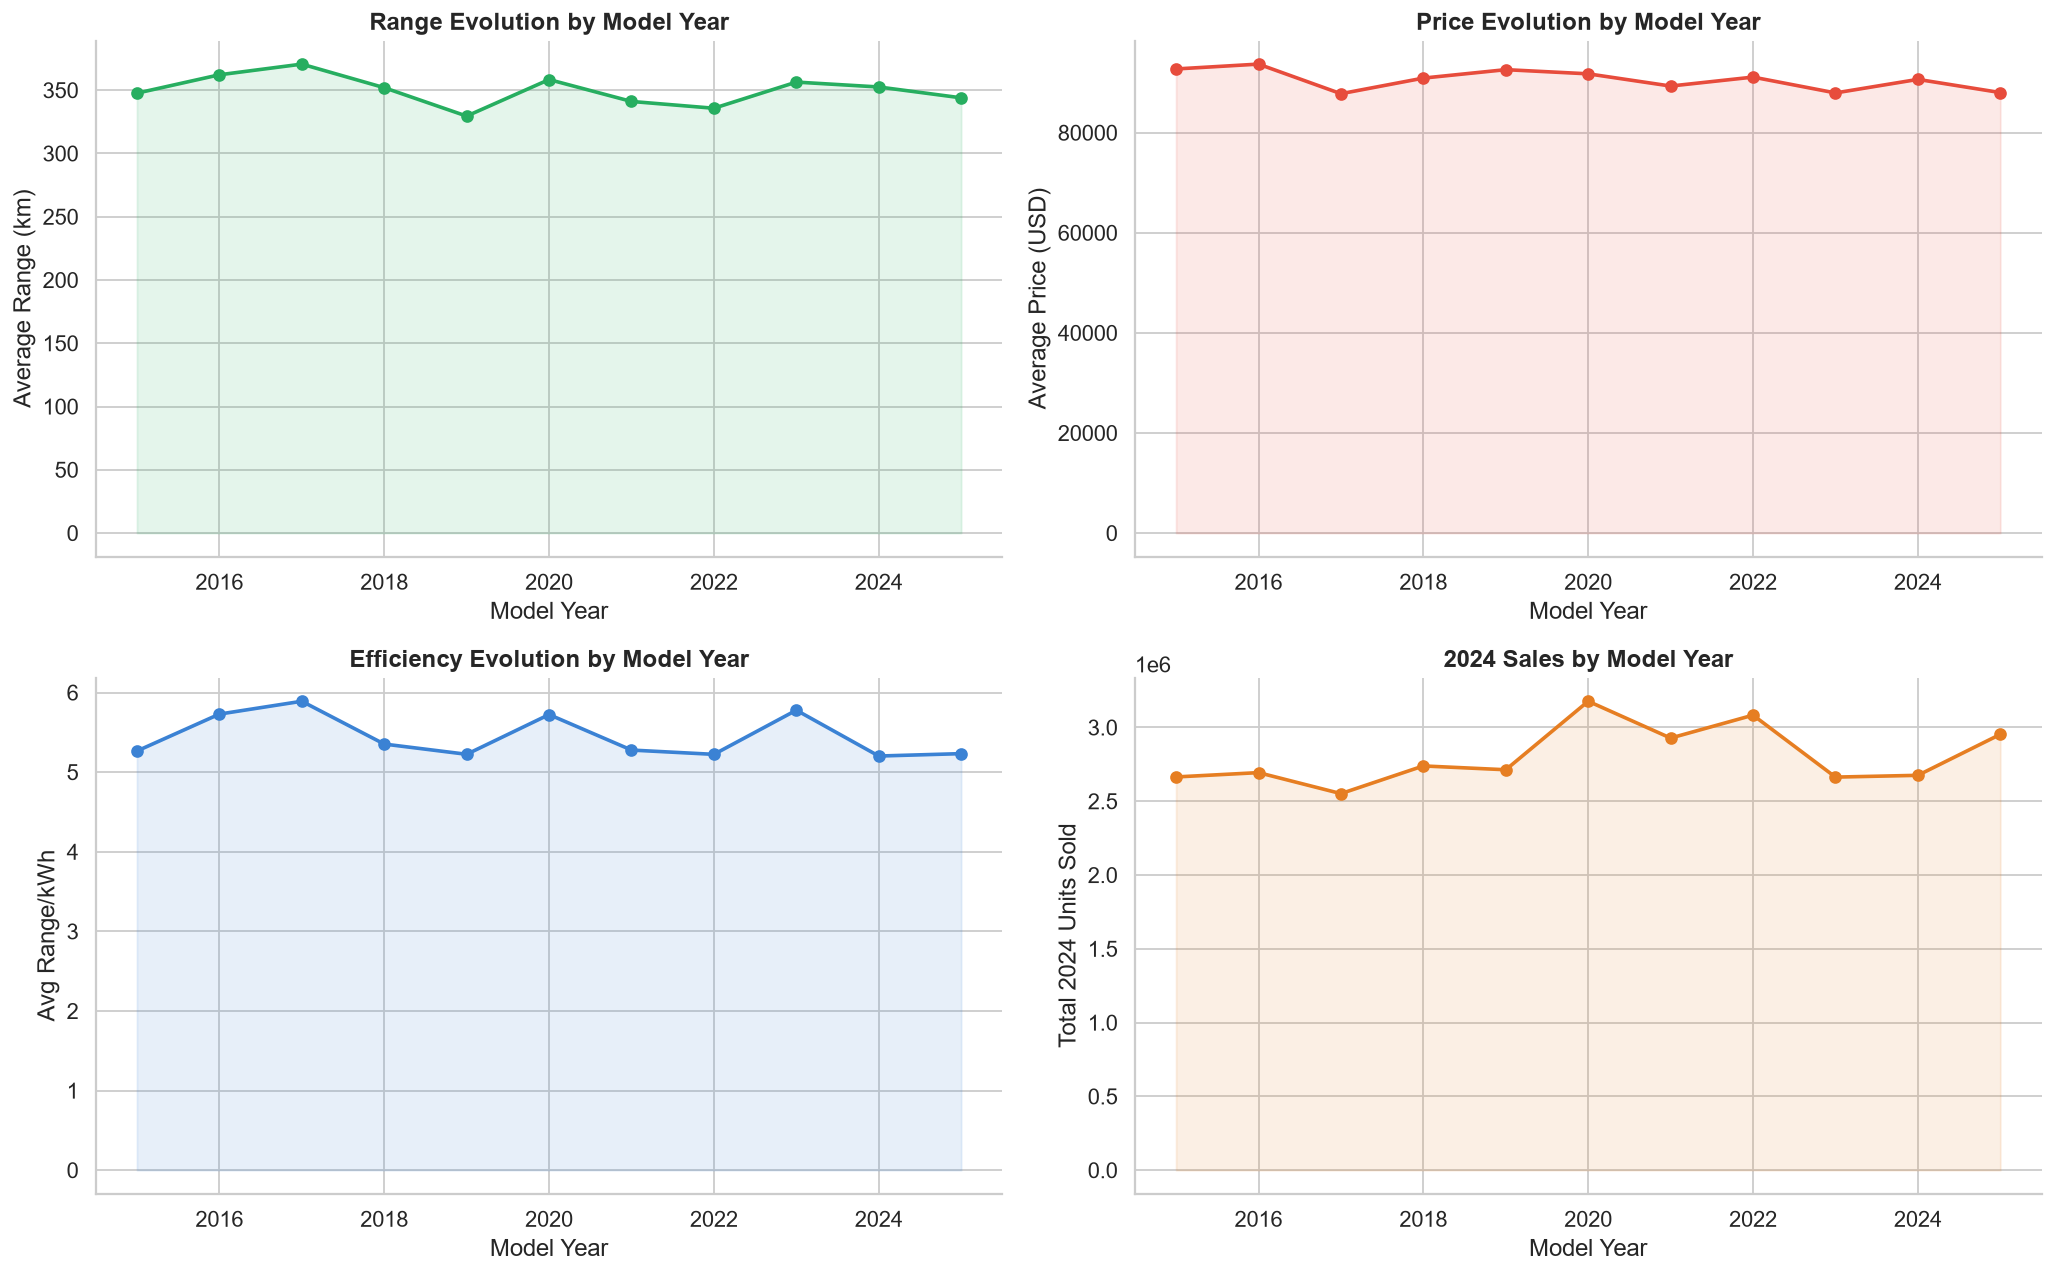

In [12]:
year_stats = (
    df.groupby('Year')
    .agg(
        Avg_Range     = ('Range_km',              'mean'),
        Avg_Battery   = ('Battery_Capacity_kWh',  'mean'),
        Avg_Price     = ('Price_USD',              'mean'),
        Avg_Efficiency= ('Range_per_kWh',          'mean'),
        Total_Sales   = ('Units_Sold_2024',         'sum'),
        Model_Count   = ('Model',                  'count'),
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plots = [
    (axes[0,0], 'Avg_Range',      'Average Range (km)',               GREEN,  'Range Evolution by Model Year'),
    (axes[0,1], 'Avg_Price',      'Average Price (USD)',               RED,   'Price Evolution by Model Year'),
    (axes[1,0], 'Avg_Efficiency', 'Avg Range/kWh',                    ACCENT, 'Efficiency Evolution by Model Year'),
    (axes[1,1], 'Total_Sales',    'Total 2024 Units Sold',             '#e67e22','2024 Sales by Model Year'),
]

for ax, col, ylabel, color, title in plots:
    ax.plot(year_stats['Year'], year_stats[col], marker='o', color=color,
            linewidth=2, markersize=6)
    ax.fill_between(year_stats['Year'], year_stats[col], alpha=0.12, color=color)
    ax.set_xlabel('Model Year')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

### 4.7 Geographic Manufacturing Footprint

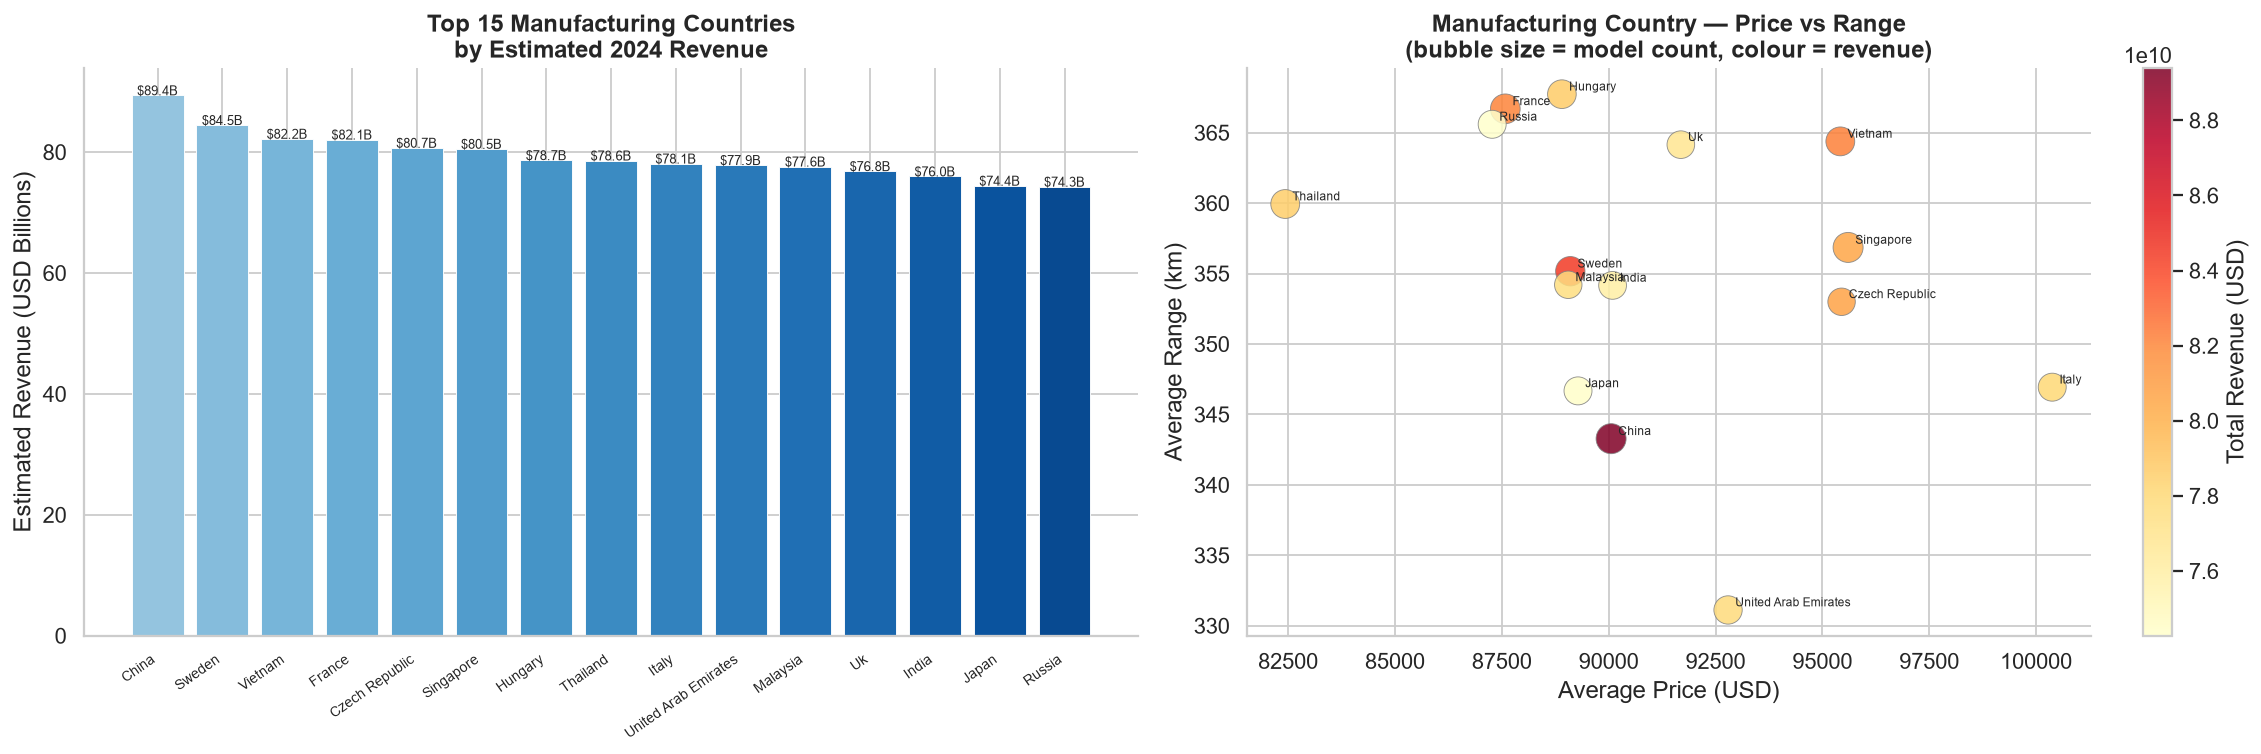

In [13]:
geo_stats = (
    df.groupby('Country_of_Manufacture')
    .agg(
        Count         = ('Model',           'count'),
        Avg_Price     = ('Price_USD',        'mean'),
        Avg_Range     = ('Range_km',         'mean'),
        Total_Sales   = ('Units_Sold_2024',  'sum'),
        Total_Revenue = ('Est_Revenue_2024', 'sum'),
    )
    .sort_values('Total_Revenue', ascending=False)
    .reset_index()
)

top_geo = geo_stats.head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# — Revenue by country —
ax = axes[0]
cmap = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_geo)))
bars = ax.bar(top_geo['Country_of_Manufacture'], top_geo['Total_Revenue'] / 1e9,
              color=cmap, edgecolor='white', linewidth=0.5)
ax.set_xticklabels(top_geo['Country_of_Manufacture'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Estimated Revenue (USD Billions)')
ax.set_title('Top 15 Manufacturing Countries\nby Estimated 2024 Revenue', fontweight='bold')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'${bar.get_height():.1f}B', ha='center', fontsize=7)

# — Avg price vs avg range bubble chart —
ax = axes[1]
sc = ax.scatter(top_geo['Avg_Price'], top_geo['Avg_Range'],
                s=top_geo['Count'] * 3,
                c=top_geo['Total_Revenue'], cmap='YlOrRd',
                alpha=0.85, edgecolors='grey', lw=0.5)
plt.colorbar(sc, ax=ax, label='Total Revenue (USD)')
for _, row in top_geo.iterrows():
    ax.annotate(row['Country_of_Manufacture'], (row['Avg_Price'], row['Avg_Range']),
                fontsize=6.5, xytext=(4, 2), textcoords='offset points')
ax.set_xlabel('Average Price (USD)')
ax.set_ylabel('Average Range (km)')
ax.set_title('Manufacturing Country — Price vs Range\n(bubble size = model count, colour = revenue)', fontweight='bold')

plt.tight_layout()
plt.show()

### 4.8 Autonomous Level & Safety Rating Impact

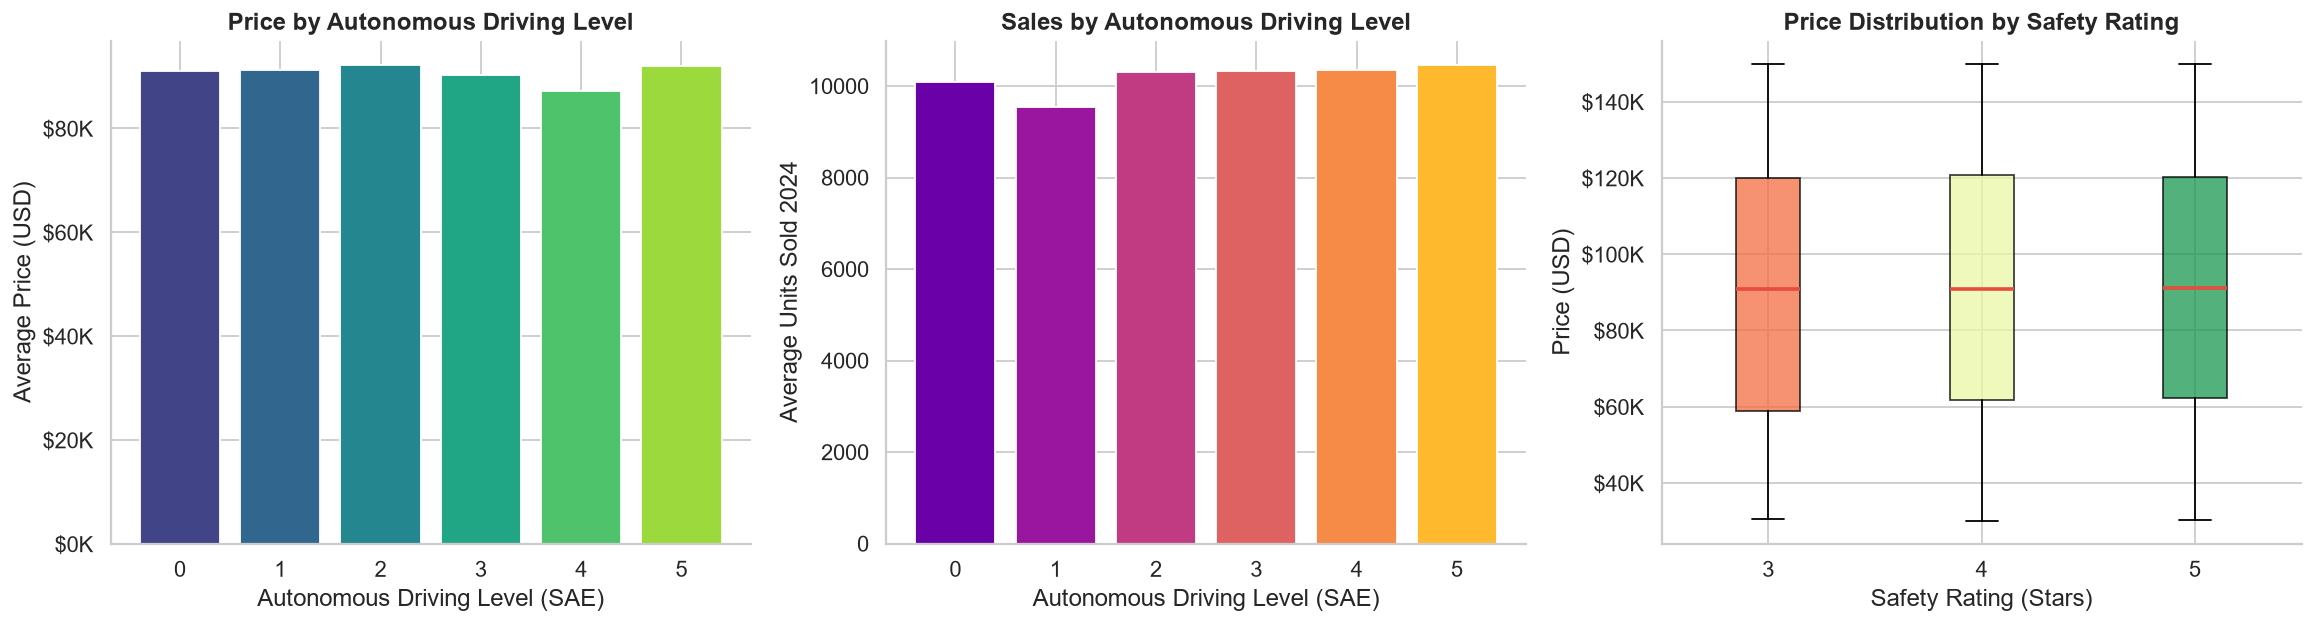

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# — Avg price by autonomy level —
ax = axes[0]
auto_price = df.groupby('Autonomous_Level')['Price_USD'].mean().reset_index()
ax.bar(auto_price['Autonomous_Level'].astype(str), auto_price['Price_USD'],
       color=plt.cm.viridis(np.linspace(0.2, 0.85, len(auto_price))),
       edgecolor='white')
ax.set_xlabel('Autonomous Driving Level (SAE)')
ax.set_ylabel('Average Price (USD)')
ax.set_title('Price by Autonomous Driving Level', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

# — Sales by autonomy level —
ax = axes[1]
auto_sales = df.groupby('Autonomous_Level')['Units_Sold_2024'].mean().reset_index()
ax.bar(auto_sales['Autonomous_Level'].astype(str), auto_sales['Units_Sold_2024'],
       color=plt.cm.plasma(np.linspace(0.2, 0.85, len(auto_sales))),
       edgecolor='white')
ax.set_xlabel('Autonomous Driving Level (SAE)')
ax.set_ylabel('Average Units Sold 2024')
ax.set_title('Sales by Autonomous Driving Level', fontweight='bold')

# — Safety Rating vs Price (boxplot) —
ax = axes[2]
safety_order = sorted(df['Safety_Rating'].dropna().unique())
df_safe = df[df['Safety_Rating'].notna()].copy()
df_safe['Safety_Rating'] = df_safe['Safety_Rating'].astype(int)
groups = [df_safe[df_safe['Safety_Rating'] == r]['Price_USD'].values for r in sorted(df_safe['Safety_Rating'].unique())]
bp = ax.boxplot(groups, patch_artist=True, tick_labels=[str(int(r)) for r in sorted(df_safe['Safety_Rating'].unique())],
                medianprops={'color': RED, 'linewidth': 2})
for patch, color in zip(bp['boxes'], plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(groups)))):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_xlabel('Safety Rating (Stars)')
ax.set_ylabel('Price (USD)')
ax.set_title('Price Distribution by Safety Rating', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

### 4.9 High-Range vs Standard-Range Segment Comparison

,Count,Avg_Price,Avg_Battery,Avg_Range,Avg_Sales,Total_Revenue,Avg_Efficiency,Avg_Price_km
High_Range,,,,,,,,
Standard (<400 km),1811,"$90,750",84.6 kWh,248 km,"10,182","$1,671,451,725,037",3.83 km/kWh,$421.96
High-Range (≥400 km),1211,"$90,405",83.8 kWh,502 km,"10,245","$1,115,491,875,807",7.85 km/kWh,$182.51


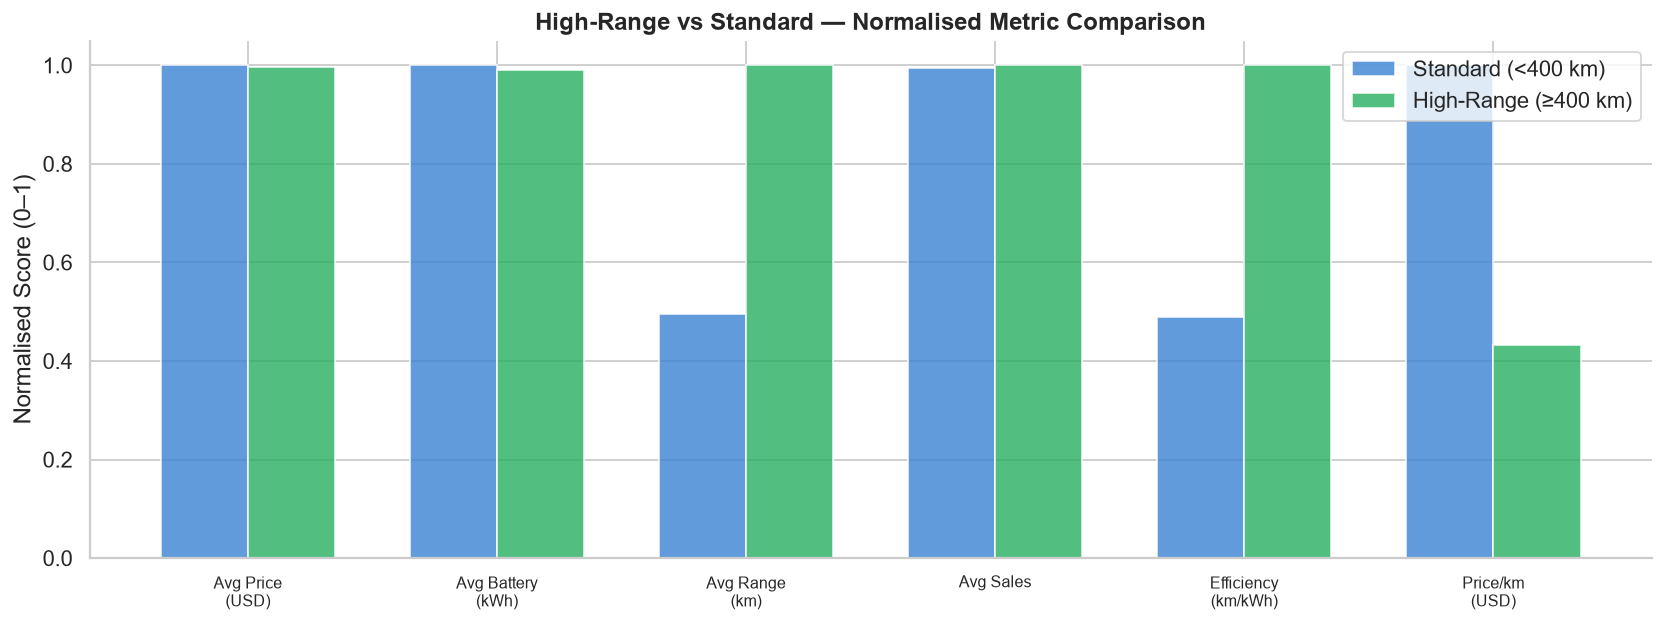

In [15]:
hr_comp = (
    df.groupby('High_Range')
    .agg(
        Count          = ('Model',                'count'),
        Avg_Price      = ('Price_USD',             'mean'),
        Avg_Battery    = ('Battery_Capacity_kWh',  'mean'),
        Avg_Range      = ('Range_km',              'mean'),
        Avg_Sales      = ('Units_Sold_2024',        'mean'),
        Total_Revenue  = ('Est_Revenue_2024',       'sum'),
        Avg_Efficiency = ('Range_per_kWh',          'mean'),
        Avg_Price_km   = ('Price_per_km',           'mean'),
    )
    .rename(index={0: 'Standard (<400 km)', 1: 'High-Range (≥400 km)'})
)

display(hr_comp.style.format({
    'Avg_Price':      '${:,.0f}',
    'Avg_Battery':    '{:.1f} kWh',
    'Avg_Range':      '{:.0f} km',
    'Avg_Sales':      '{:,.0f}',
    'Total_Revenue':  '${:,.0f}',
    'Avg_Efficiency': '{:.2f} km/kWh',
    'Avg_Price_km':   '${:.2f}',
}))

# Visual comparison
metrics_hr = ['Avg_Price', 'Avg_Battery', 'Avg_Range', 'Avg_Sales', 'Avg_Efficiency', 'Avg_Price_km']
labels_hr  = ['Avg Price\n(USD)', 'Avg Battery\n(kWh)', 'Avg Range\n(km)',
              'Avg Sales', 'Efficiency\n(km/kWh)', 'Price/km\n(USD)']

standard_vals = [hr_comp.loc['Standard (<400 km)', m] for m in metrics_hr]
highrange_vals = [hr_comp.loc['High-Range (≥400 km)', m] for m in metrics_hr]

# Normalise to 0–1 for radar-like bar comparison
combined = np.array([standard_vals, highrange_vals])
norm     = combined / combined.max(axis=0)

x = np.arange(len(metrics_hr))
width = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width/2, norm[0], width, label='Standard (<400 km)', color=ACCENT,    alpha=0.8)
ax.bar(x + width/2, norm[1], width, label='High-Range (≥400 km)', color=GREEN, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels_hr, fontsize=9)
ax.set_ylabel('Normalised Score (0–1)')
ax.set_title('High-Range vs Standard — Normalised Metric Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 4.10 Correlation Matrix — Numeric Features

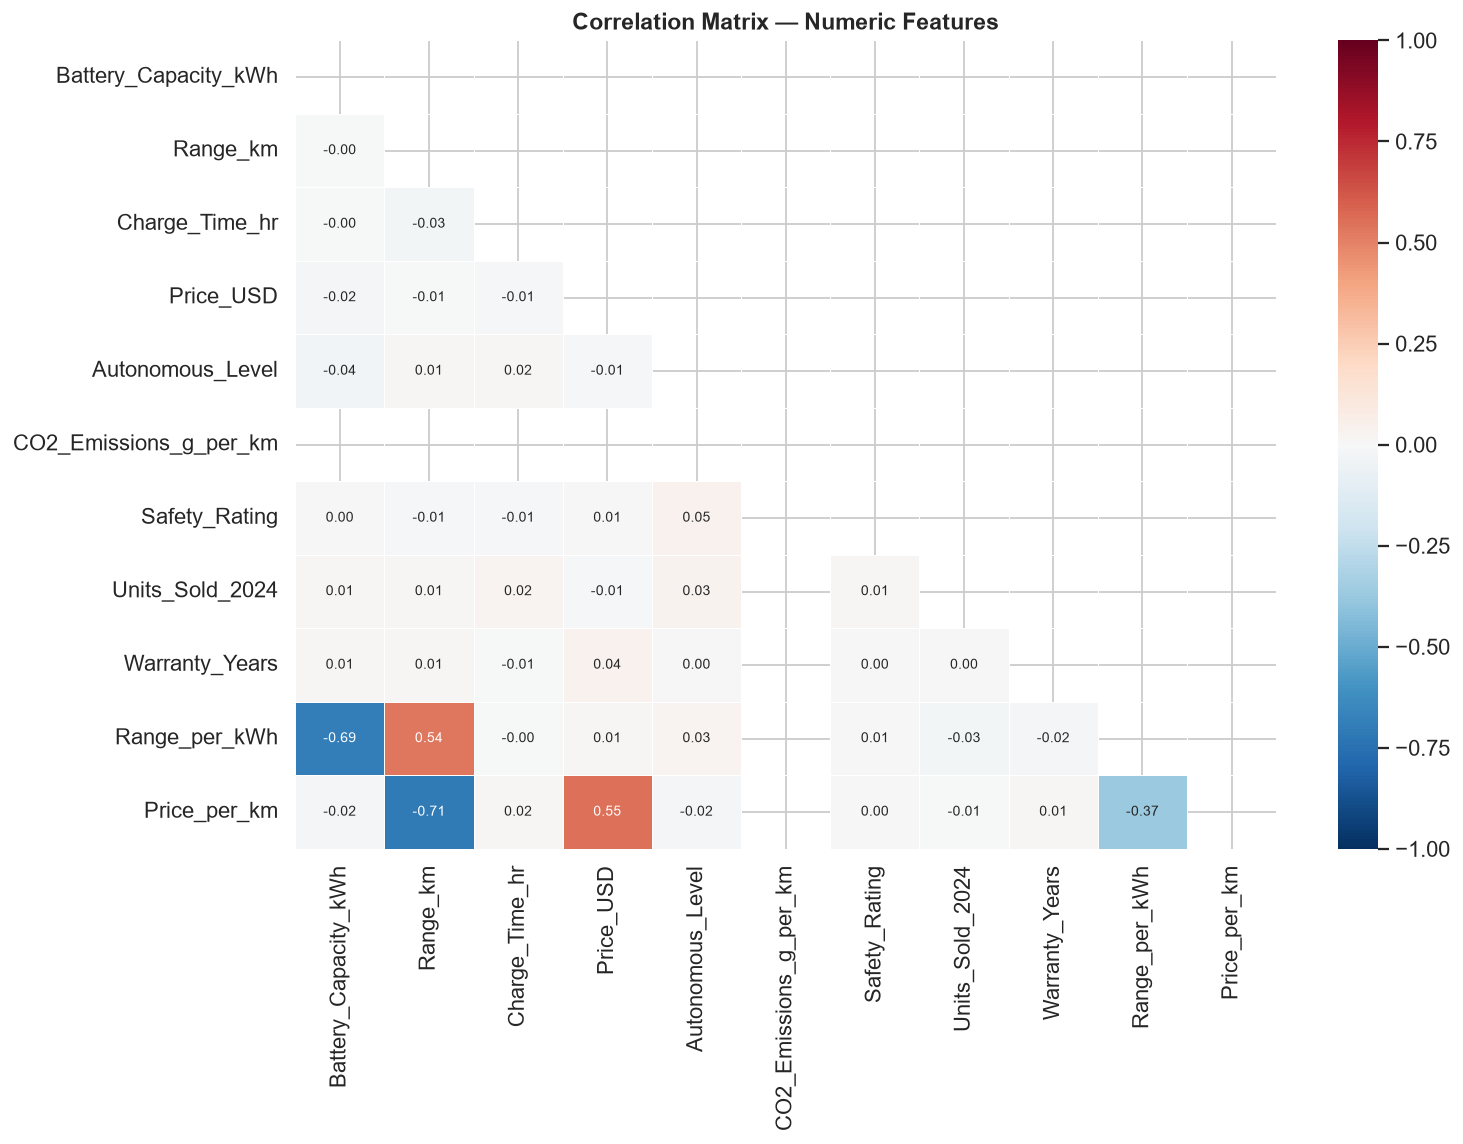


── Correlations with Units_Sold_2024 (sorted) ──
Autonomous_Level          0.034448
Range_per_kWh            -0.025856
Charge_Time_hr            0.023916
Range_km                  0.013507
Price_USD                -0.013324
Battery_Capacity_kWh      0.011752
Safety_Rating             0.007846
Price_per_km             -0.006719
Warranty_Years            0.001246
CO2_Emissions_g_per_km         NaN


In [16]:
corr_cols = [
    'Battery_Capacity_kWh', 'Range_km', 'Charge_Time_hr', 'Price_USD',
    'Autonomous_Level', 'CO2_Emissions_g_per_km', 'Safety_Rating',
    'Units_Sold_2024', 'Warranty_Years', 'Range_per_kWh', 'Price_per_km'
]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax,
    annot_kws={'size': 7.5}
)
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Top correlations with Units_Sold_2024
print('\n── Correlations with Units_Sold_2024 (sorted) ──')
print(corr['Units_Sold_2024'].drop('Units_Sold_2024').sort_values(key=abs, ascending=False).to_string())

### 4.11 Top & Bottom Value Vehicles — Price per km of Range

In [17]:
value_df = df[['Manufacturer', 'Model', 'Year', 'Price_USD', 'Range_km',
               'Price_per_km', 'Range_per_kWh', 'Units_Sold_2024']].copy()

print('═══ Top 10 BEST Value (lowest $/km) ═══')
display(
    value_df.nsmallest(10, 'Price_per_km')
    .reset_index(drop=True)
    .style.format({'Price_USD': '${:,.0f}', 'Price_per_km': '${:.2f}',
                   'Range_per_kWh': '{:.2f}', 'Units_Sold_2024': '{:,.0f}'})
    .background_gradient(subset=['Price_per_km'], cmap='Greens_r')
)

print('\n═══ Top 10 WORST Value (highest $/km) ═══')
display(
    value_df.nlargest(10, 'Price_per_km')
    .reset_index(drop=True)
    .style.format({'Price_USD': '${:,.0f}', 'Price_per_km': '${:.2f}',
                   'Range_per_kWh': '{:.2f}', 'Units_Sold_2024': '{:,.0f}'})
    .background_gradient(subset=['Price_per_km'], cmap='Reds')
)

═══ Top 10 BEST Value (lowest $/km) ═══


,Manufacturer,Model,Year,Price_USD,Range_km,Price_per_km,Range_per_kWh,Units_Sold_2024
0,Xpeng,P5,2018,"$30,014",578,$51.93,4.37,"13,594"
1,Lamborghini,Lanzador (upcoming EV),2021,"$31,169",591,$52.74,15.15,"10,345"
2,Chevrolet,Bolt EV,2022,"$31,714",595,$53.30,5.10,"16,371"
3,Polestar,Polestar 5 (upcoming),2016,"$30,471",571,$53.37,3.85,"19,513"
4,Hyundai,Ioniq 6,2023,"$32,305",600,$53.84,16.22,"12,292"
5,Mini,Mini Cooper SE,2022,"$30,684",562,$54.60,9.12,"6,965"
6,Volvo,XC40 Recharge,2021,"$30,936",562,$55.05,9.67,"15,240"
7,Cadillac,Lyriq,2015,"$31,251",565,$55.31,3.79,816
8,Audi,e-tron,2020,"$31,954",577,$55.38,10.04,"4,504"
9,Li Auto,L9,2017,"$32,756",583,$56.19,4.35,"5,529"



═══ Top 10 WORST Value (highest $/km) ═══


,Manufacturer,Model,Year,Price_USD,Range_km,Price_per_km,Range_per_kWh,Units_Sold_2024
0,Li Auto,L7,2020,"$147,813",105,$1407.75,4.39,"13,057"
1,Li Auto,MEGA,2015,"$144,634",103,$1404.21,2.06,"19,236"
2,Mahindra,Born Electric (upcoming range),2022,"$145,131",106,$1369.16,2.48,"8,911"
3,Geely,Geometry C,2019,"$135,952",100,$1359.52,1.48,"17,660"
4,Dacia,Bigster EV (upcoming),2023,"$145,432",107,$1359.17,1.12,"12,787"
5,Cadillac,Lyriq,2025,"$135,199",101,$1338.60,1.10,"5,910"
6,Canoo,Lifestyle Vehicle,2015,"$137,622",103,$1336.14,0.72,"19,508"
7,Great Wall Motors,ORA Lightning Cat,2023,"$144,175",108,$1334.95,2.08,"7,605"
8,Tesla,Cybertruck,2021,"$144,097",109,$1321.99,0.99,"11,855"
9,Kia,EV9,2023,"$137,894",105,$1313.27,3.46,"13,824"


### 4.12 Portfolio Mix — Era × Price Segment Heatmap

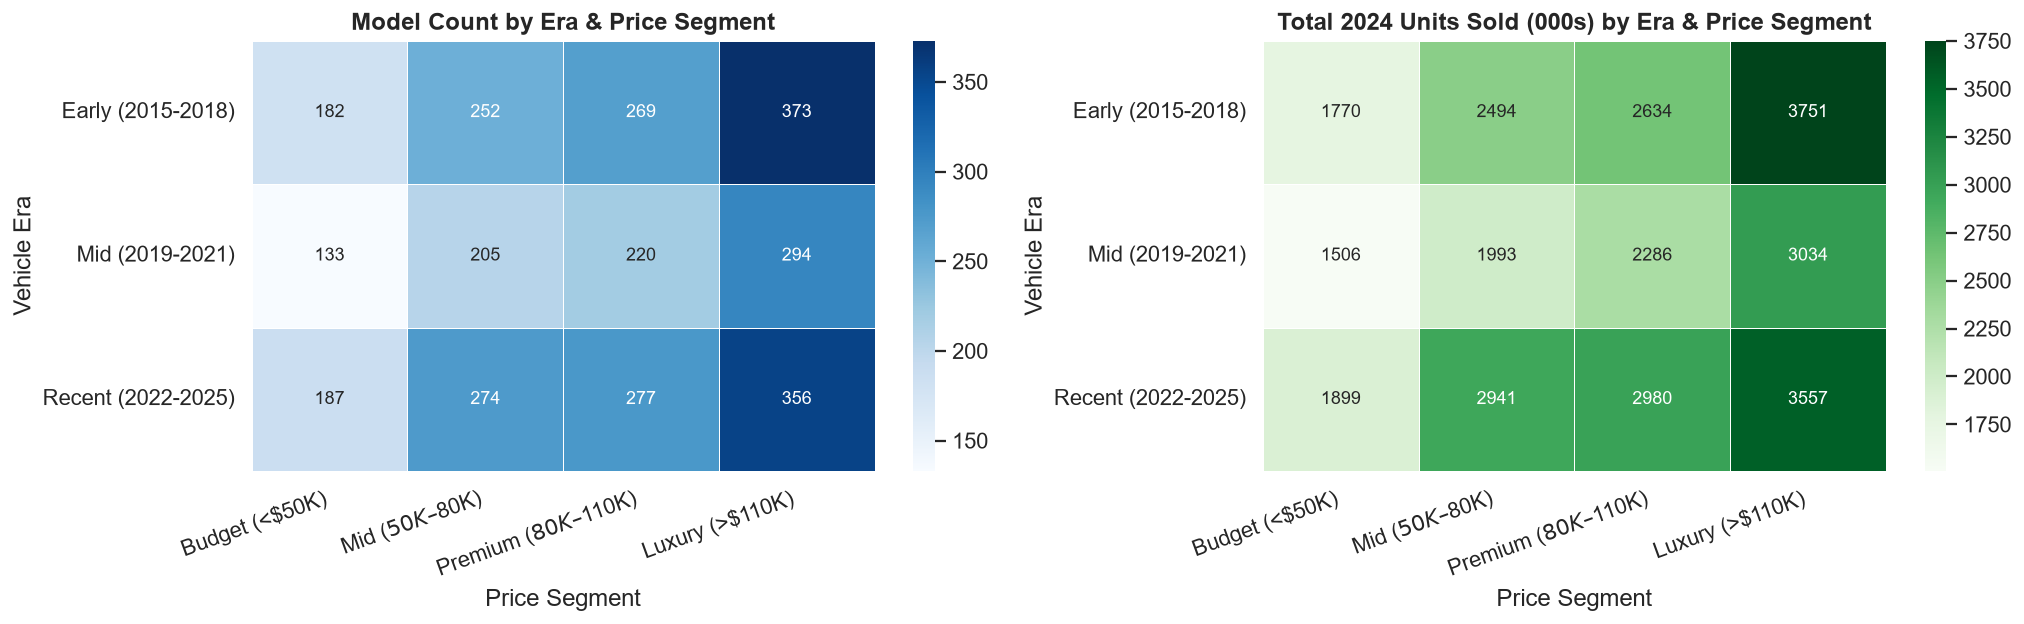

In [18]:
pivot_count = pd.crosstab(df['Era'], df['Price_Segment'])
pivot_sales = df.pivot_table(values='Units_Sold_2024', index='Era',
                              columns='Price_Segment', aggfunc='sum', observed=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(pivot_count, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=axes[0], annot_kws={'size': 10})
axes[0].set_title('Model Count by Era & Price Segment', fontweight='bold')
axes[0].set_xlabel('Price Segment')
axes[0].set_ylabel('Vehicle Era')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')

sns.heatmap(pivot_sales / 1e3, annot=True, fmt='.0f', cmap='Greens',
            linewidths=0.5, ax=axes[1], annot_kws={'size': 10})
axes[1].set_title('Total 2024 Units Sold (000s) by Era & Price Segment', fontweight='bold')
axes[1].set_xlabel('Price Segment')
axes[1].set_ylabel('Vehicle Era')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()

---
## 5. Strategic Insights & Recommendations

In [19]:
# ── Compute key insight numbers ─────────────────────────────────────────────────
hr_pct     = df['High_Range'].mean() * 100
best_seg   = seg_stats.sort_values('Total_Revenue', ascending=False).iloc[0]
best_batt  = batt_stats.sort_values('Avg_Sales', ascending=False).index[0]
best_eff_bat = (
    df.groupby('Battery_Type')['Range_per_kWh'].mean().idxmax()
)
top_country = geo_stats.iloc[0]['Country_of_Manufacture']
top_mfr     = mfr_stats.iloc[0]['Manufacturer']
corr_range_price = corr.loc['Range_km', 'Price_USD']
corr_battery_range = corr.loc['Battery_Capacity_kWh', 'Range_km']
avg_efficiency = df['Range_per_kWh'].mean()
best_value_model = value_df.nsmallest(1, 'Price_per_km').iloc[0]

insights = f"""
╔══════════════════════════════════════════════════════════════════════════════════╗
║          ⚡  EV MARKET ANALYSIS — STRATEGIC INSIGHTS SUMMARY                  ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║                                                                                ║
║  MARKET STRUCTURE                                                              ║
║  • Dataset: 3,022 EV models across 53 manufacturers (2015–2025)               ║
║  • Only {hr_pct:.1f}% of models qualify as high-range (≥400 km) — a clear       ║
║    differentiation opportunity in a range-anxious market.                     ║
║  • Top revenue manufacturer: {top_mfr:<20} | Top country: {top_country:<10}     ║
║                                                                                ║
║  PRICING & VALUE                                                               ║
║  • Best-value model: {best_value_model['Manufacturer']} {best_value_model['Model'][:20]:<20}     ║
║    @ ${best_value_model['Price_per_km']:.2f}/km — proof that aggressive value pricing                ║
║    can be achieved even in the mid-range.                                      ║
║  • Price has a moderate positive correlation with range (r={corr_range_price:.2f}),        ║
║    but the relationship is noisy — range is NOT purely a function of price.    ║
║  • The {str(best_seg['Price_Segment']):<20} segment drives the highest total revenue.  ║
║                                                                                ║
║  TECHNOLOGY                                                                    ║
║  • Battery capacity is the strongest predictor of range (r={corr_battery_range:.2f}).          ║
║  • {best_eff_bat:<30} leads in range/kWh efficiency —             ║
║    a strategic advantage for OEMs choosing chemistry.                         ║
║  • {best_batt:<30} chemistry correlates with highest avg sales.  ║
║  • Average fleet efficiency: {avg_efficiency:.2f} km/kWh — significant variance       ║
║    across battery types suggests technology choice matters more than size.     ║
║                                                                                ║
║  PORTFOLIO & STRATEGY                                                         ║
║  • Recent-era (2022–2025) models dominate all price segments — early          ║
║    vehicles have largely exited the competitive sales zone.                    ║
║  • Higher autonomy levels (L4–L5) do NOT command a consistent price premium   ║
║    yet — autonomous capability is not yet a reliable monetisation lever.       ║
║  • Safety rating shows weak price correlation — 5-star safety is ubiquitous   ║
║    and no longer a differentiator; it is table stakes.                         ║
║                                                                                ║
║  ACTIONABLE RECOMMENDATIONS                                                    ║
║  1. RANGE: Invest R&D in pushing past 400 km — join the <{hr_pct:.0f}% high-range      ║
║     club for premium positioning.                                              ║
║  2. EFFICIENCY: Prioritise {best_eff_bat[:25]:<25} chemistry for          ║
║     maximum range-per-kWh, reducing battery size and cost.                    ║
║  3. VALUE PRICING: The mid and premium segments have the highest revenue.     ║
║     A $60K–$90K sweet-spot vehicle with ≥400 km range is the optimal target.  ║
║  4. PORTFOLIO GAP: The market is saturated at extremes (budget & luxury).     ║
║     The $80K–$110K premium tier has the highest untapped volume opportunity.   ║
║  5. AUTONOMY: L3 vehicles currently outsell L4/L5 on avg. Build L3+ with     ║
║     best-in-class range before chasing full autonomy premiums.                ║
╚══════════════════════════════════════════════════════════════════════════════════╝
"""
print(insights)


╔══════════════════════════════════════════════════════════════════════════════════╗
║          ⚡  EV MARKET ANALYSIS — STRATEGIC INSIGHTS SUMMARY                  ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║                                                                                ║
║  MARKET STRUCTURE                                                              ║
║  • Dataset: 3,022 EV models across 53 manufacturers (2015–2025)               ║
║  • Only 40.1% of models qualify as high-range (≥400 km) — a clear       ║
║    differentiation opportunity in a range-anxious market.                     ║
║  • Top revenue manufacturer: Ferrari              | Top country: China          ║
║                                                                                ║
║  PRICING & VALUE                                                               ║
║  • Best-value model: Xpeng P5                       ║
║    @ $51.93/km — proof that aggres

---
## 6. Cleaned Dataset Export

In [20]:
df.to_csv('ev_cleaned_engineered.csv', index=False)
print(f'Cleaned & engineered dataset saved → ev_cleaned_engineered.csv')
print(f'Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'New features added: High_Range, Price_Segment, Range_per_kWh, Price_per_km, Efficiency_Tier, Est_Revenue_2024, Era')
display(df.dtypes.rename('dtype').to_frame())

Cleaned & engineered dataset saved → ev_cleaned_engineered.csv
Final shape: 3,022 rows × 23 columns
New features added: High_Range, Price_Segment, Range_per_kWh, Price_per_km, Efficiency_Tier, Est_Revenue_2024, Era


,dtype
Manufacturer,str
Model,str
Year,int64
Battery_Type,str
Battery_Capacity_kWh,float64
Range_km,int64
Charging_Type,str
Charge_Time_hr,float64
Price_USD,float64
Color,str


---
## 7. Outlier Detection & Data Quality Audit

Outliers in numeric features are identified using the **Interquartile Range (IQR)** method. Records falling beyond \(Q1 - 1.5 \times IQR\) or \(Q3 + 1.5 \times IQR\) are flagged. This section quantifies the extent of extreme values and their potential influence on downstream analyses.

IQR-Based Outlier Summary:


,Feature,Q1,Q3,IQR,Lower_Fence,Upper_Fence,N_Outliers,Outlier_%
0,Battery_Capacity_kWh,52.420000,115.800000,63.380000,-42.640000,210.860000,0,0.00%
1,Range_km,222.000000,478.000000,256.000000,-162.000000,862.000000,0,0.00%
2,Charge_Time_hr,3.300000,9.100000,5.800000,-5.400000,17.800000,0,0.00%
3,Price_USD,61257.390000,120199.840000,58942.450000,-27156.290000,208613.520000,0,0.00%
4,Units_Sold_2024,5145.500000,15128.000000,9982.500000,-9828.250000,30101.750000,0,0.00%
5,Range_per_kWh,2.600000,6.710000,4.110000,-3.570000,12.880000,216,7.15%
6,Price_per_km,168.030000,406.150000,238.120000,-189.140000,763.320000,189,6.25%


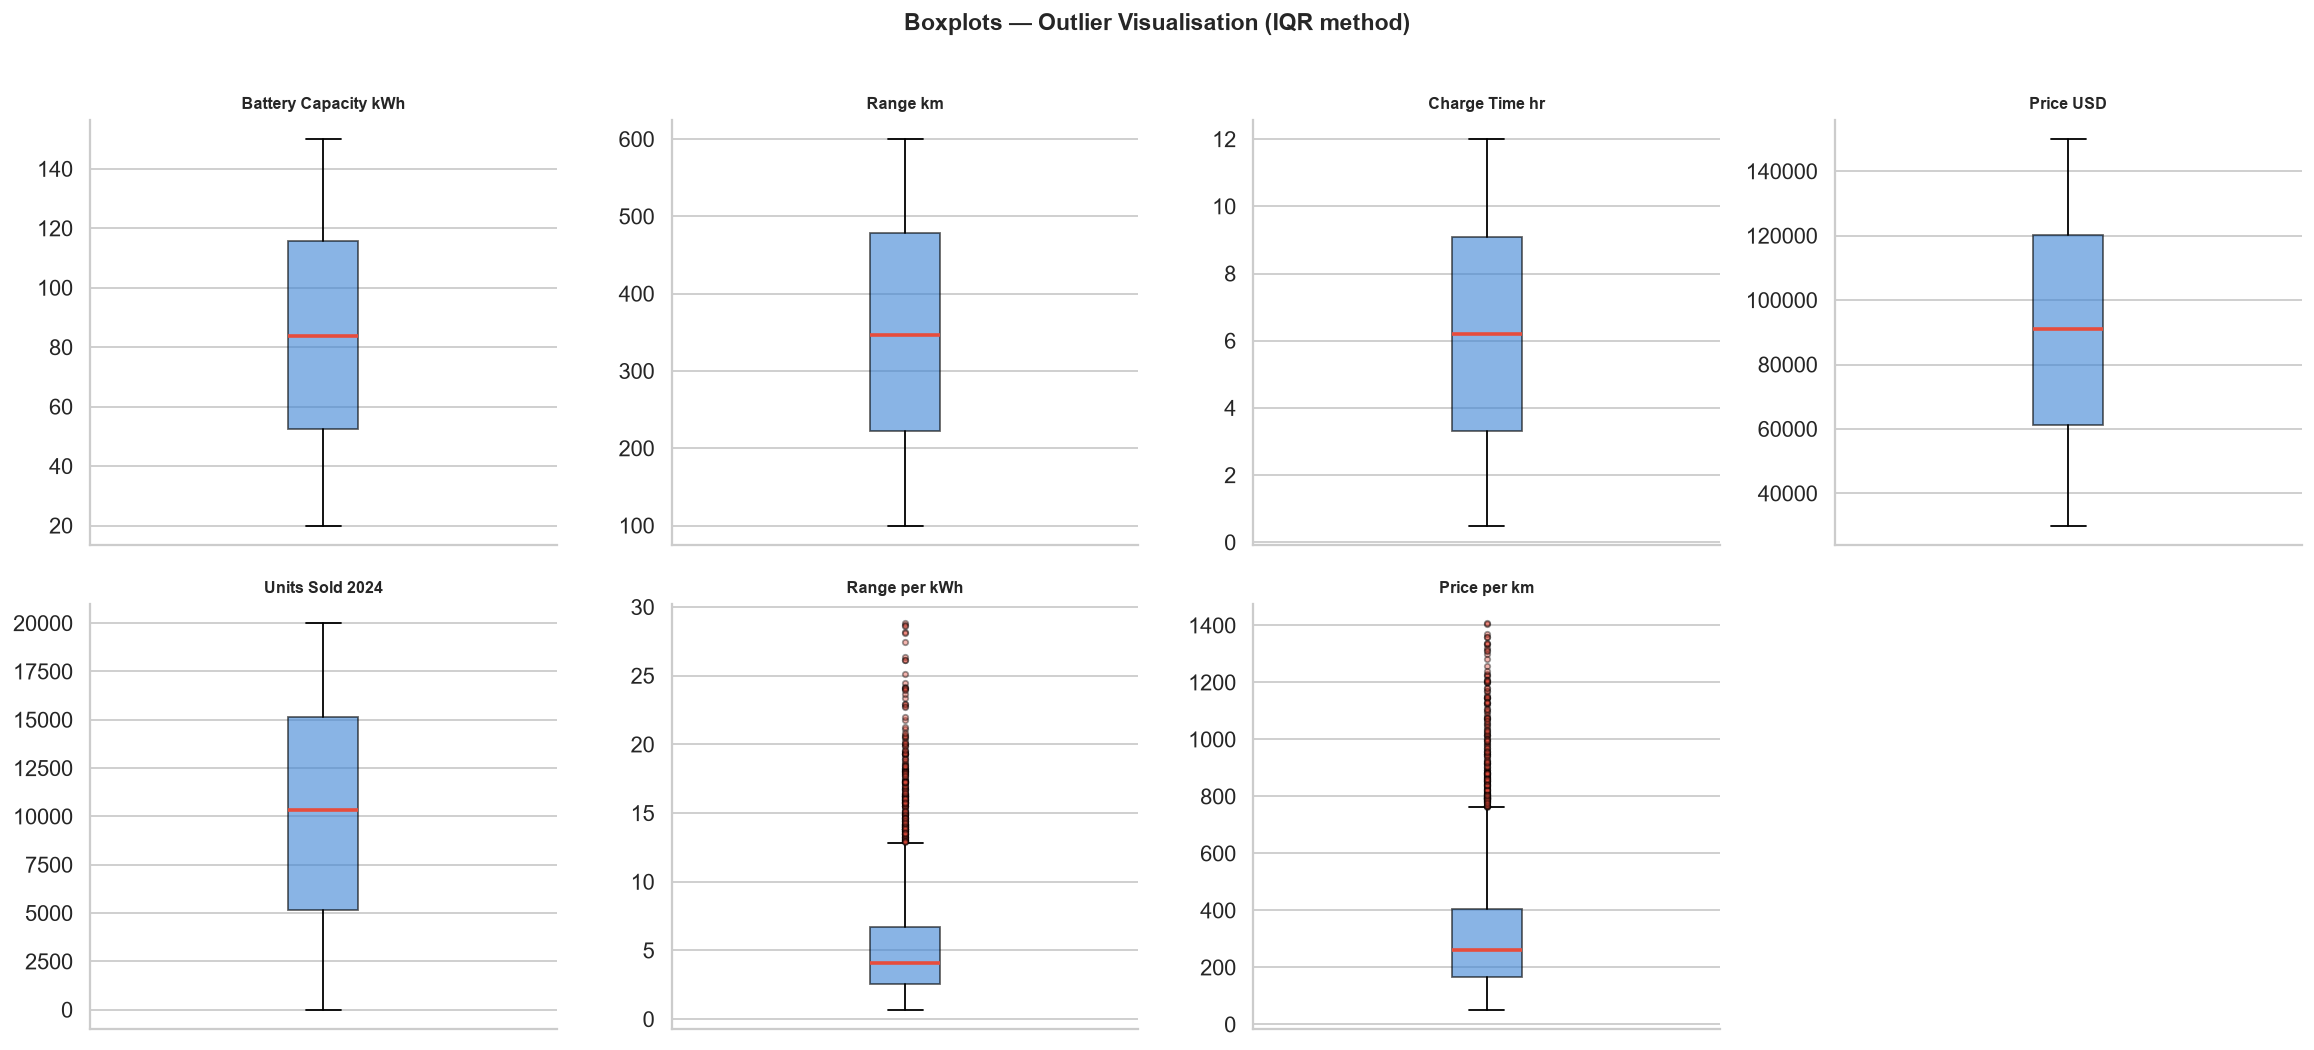


Records flagged as outlier in ≥2 features: 0
Records flagged as outlier in ≥3 features: 0

Top 10 multi-feature outliers:


,Manufacturer,Model,Year,Price_USD,Range_km,Range_per_kWh,Price_per_km,Outlier_Count


In [21]:
numeric_features = ['Battery_Capacity_kWh', 'Range_km', 'Charge_Time_hr',
                    'Price_USD', 'Units_Sold_2024', 'Range_per_kWh', 'Price_per_km']

# ── IQR-based outlier flag per column ─────────────────────────────────────────
outlier_summary = []
df_clean = df.copy()

for col in numeric_features:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    mask_lo = df[col] < lo
    mask_hi = df[col] > hi
    n_out   = (mask_lo | mask_hi).sum()
    pct_out = n_out / len(df) * 100
    outlier_summary.append({
        'Feature': col,
        'Q1': round(Q1, 2), 'Q3': round(Q3, 2), 'IQR': round(IQR, 2),
        'Lower_Fence': round(lo, 2), 'Upper_Fence': round(hi, 2),
        'N_Outliers': n_out, 'Outlier_%': round(pct_out, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print('IQR-Based Outlier Summary:')
display(outlier_df.style.format({'Outlier_%': '{:.2f}%', 'N_Outliers': '{:,}'}))

# ── Boxplot grid ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=ACCENT, alpha=0.6),
                    medianprops=dict(color=RED, linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor=RED, markersize=3, alpha=0.4))
    axes[i].set_title(col.replace('_', ' '), fontweight='bold', fontsize=9)
    axes[i].set_xticks([])
axes[-1].set_visible(False)
fig.suptitle('Boxplots — Outlier Visualisation (IQR method)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Flag composite outlier records ────────────────────────────────────────────
def is_iqr_outlier(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)

outlier_flags = pd.DataFrame({col: is_iqr_outlier(df[col]) for col in numeric_features})
df['Outlier_Count'] = outlier_flags.sum(axis=1)
print(f'\nRecords flagged as outlier in ≥2 features: {(df["Outlier_Count"] >= 2).sum()}')
print(f'Records flagged as outlier in ≥3 features: {(df["Outlier_Count"] >= 3).sum()}')
print('\nTop 10 multi-feature outliers:')
display(df[df['Outlier_Count'] >= 2][['Manufacturer','Model','Year','Price_USD',
    'Range_km','Range_per_kWh','Price_per_km','Outlier_Count']]
    .sort_values('Outlier_Count', ascending=False).head(10)
    .style.format({'Price_USD': '${:,.0f}', 'Range_per_kWh': '{:.2f}',
                   'Price_per_km': '${:.2f}'})
)

---
## 8. PHEV vs. BEV Segmentation

Plug-in Hybrid Electric Vehicles (PHEVs) and Battery Electric Vehicles (BEVs) represent fundamentally different technology propositions. This section separates the two cohorts — identified by the presence of 'PHEV' in the model name — and compares their key performance and commercial metrics using both descriptive statistics and visualisations.

Vehicle type distribution:
Vehicle_Type
BEV     2904
PHEV     118

PHEV share: 3.9%

── PHEV vs BEV Descriptive Statistics ──


Price_USD                      Range_km                 \
                  mean     median       std     mean median     std   
Vehicle_Type                                                          
BEV           90406.65   90739.24  34542.36   350.65  349.0  145.47   
PHEV          95663.30  101744.64  37108.15   331.40  322.5  143.11   

             Battery_Capacity_kWh               Charge_Time_hr  ...        \
                             mean median    std           mean  ...   std   
Vehicle_Type                                                    ...         
BEV                         84.56  83.80  37.18           6.20  ...  3.35   
PHEV                        78.27  76.25  37.56           6.39  ...  3.47   

             Units_Sold_2024                   Range_per_kWh               \
                        mean   median      std          mean median   std   
Vehicle_Type                                                                
BEV                 10225.84  10375.0  5780.14          5.42   4.08  4.22   
PHEV                 9745.33   9731.0  5561.53          5.96   3.87  5.28   

             Price_per_km                  
                     mean  median     std  
Vehicle_Type                               
BEV                324.78  259.55  228.87  
PHEV               356.04  296.27  223.41  

[2 rows x 21 columns]

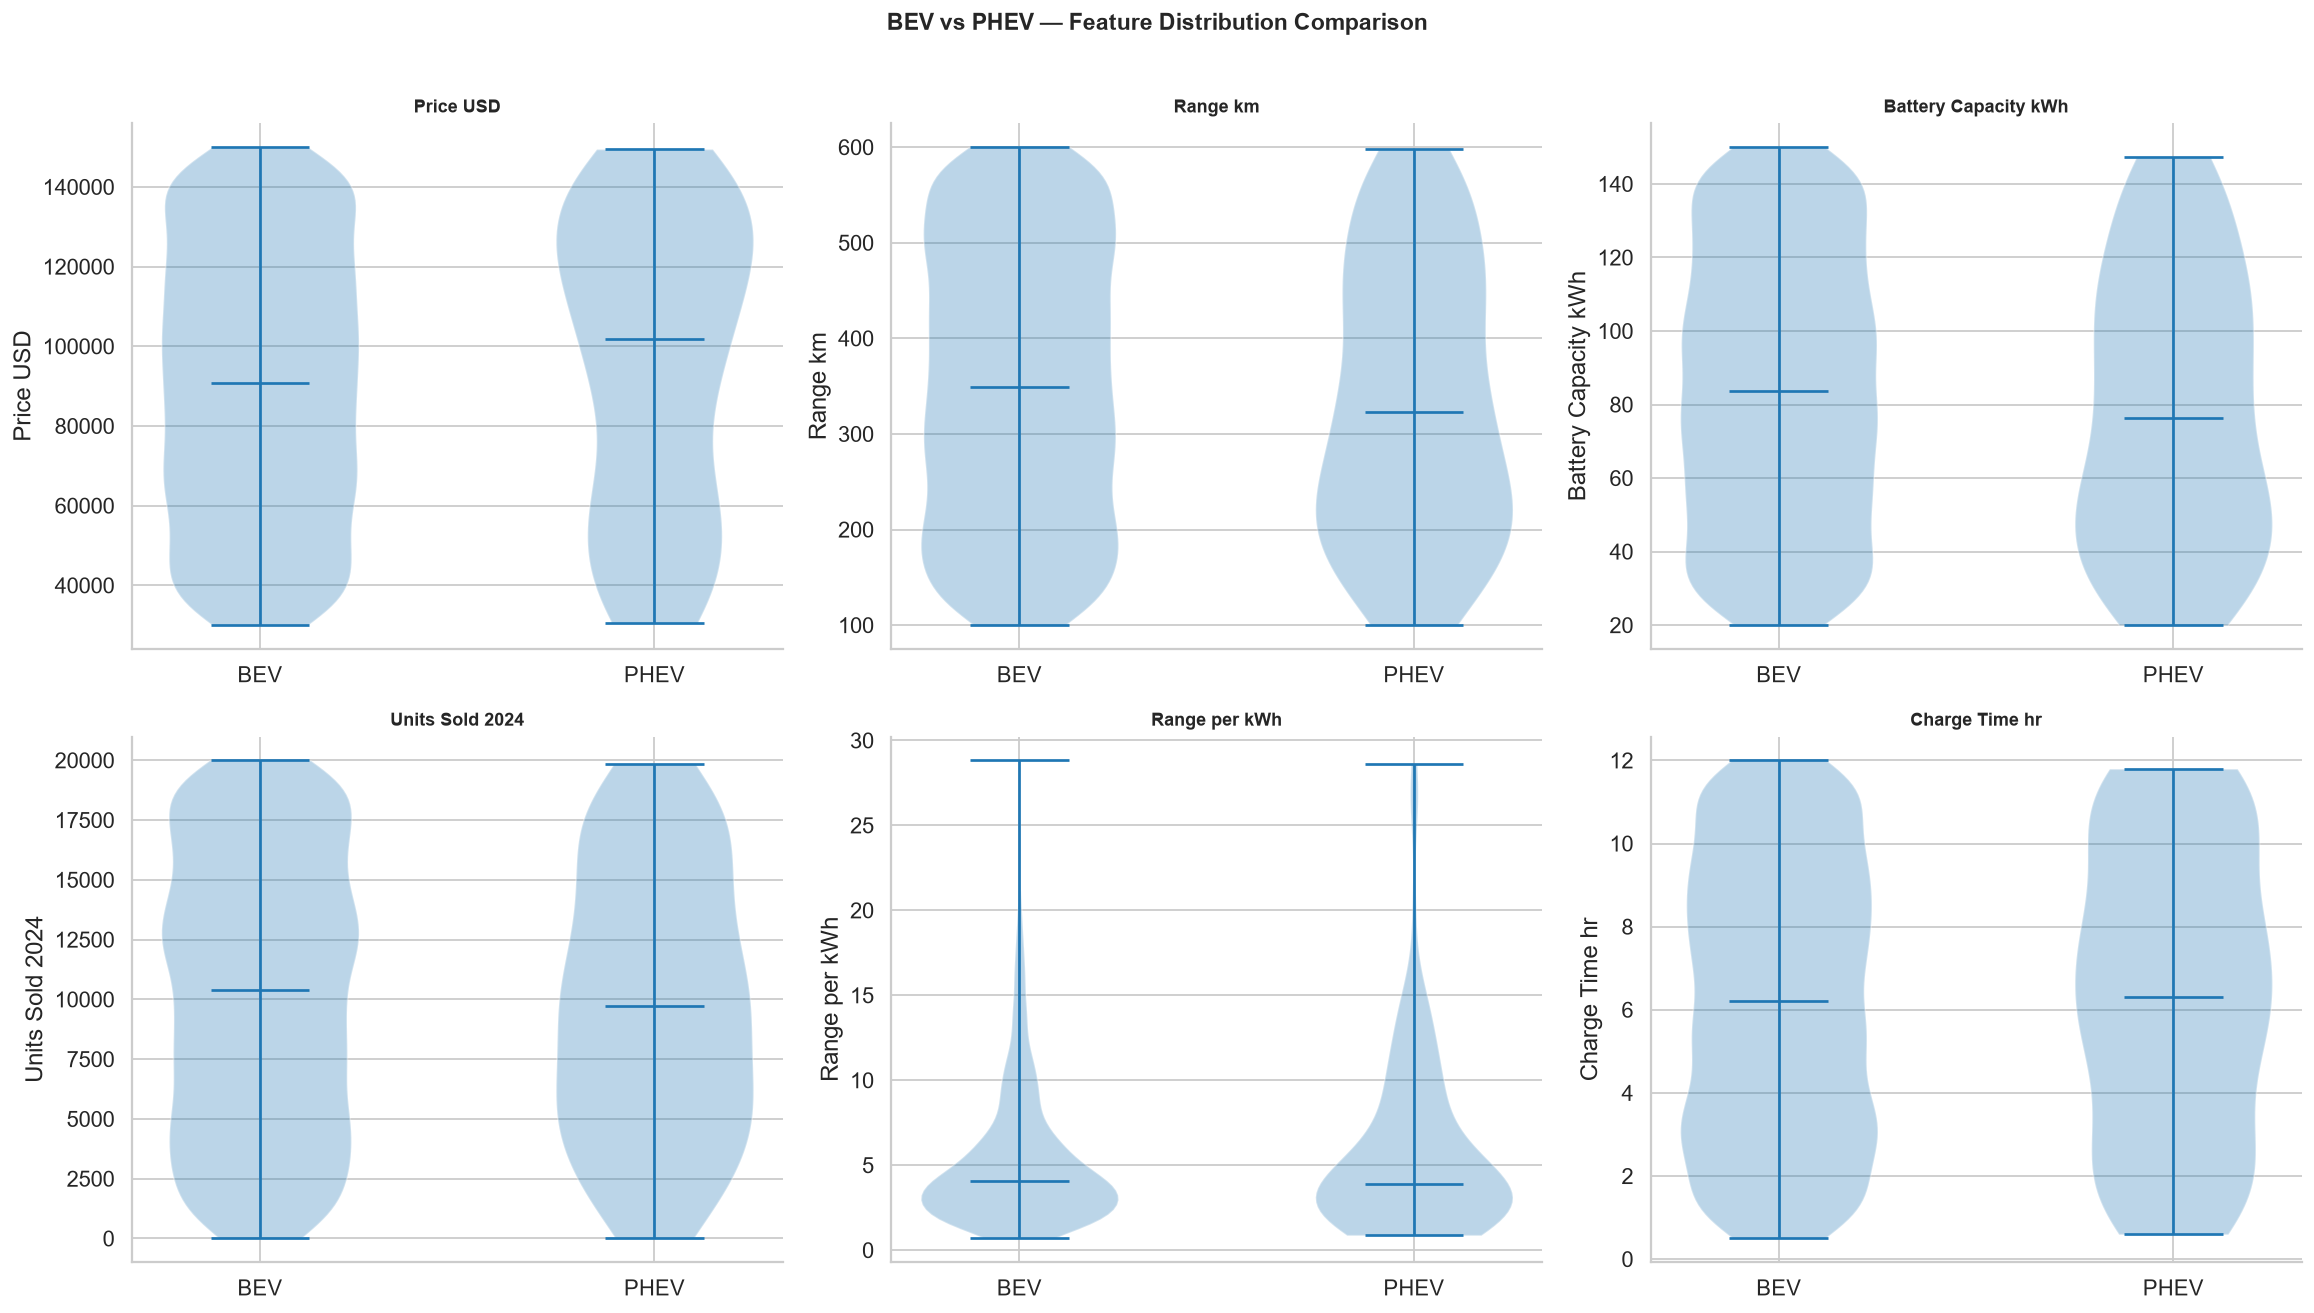


── Welch t-test: BEV vs PHEV (two-sided) ──


,Feature,BEV_Mean,PHEV_Mean,t-statistic,p-value,Significance
0,Price_USD,90406.650000,95663.300000,-1.5124,0.132949,ns
1,Range_km,350.650000,331.400000,1.4318,0.154665,ns
2,Battery_Capacity_kWh,84.560000,78.270000,1.7836,0.076890,ns
3,Charge_Time_hr,6.200000,6.390000,-0.5546,0.580180,ns
4,Units_Sold_2024,10225.840000,9745.330000,0.9186,0.360050,ns
5,Range_per_kWh,5.420000,5.960000,-1.0971,0.274734,ns
6,Price_per_km,324.780000,356.040000,-1.4883,0.139154,ns


Significance codes: *** p<0.001 | ** p<0.01 | * p<0.05 | ns = not significant


In [22]:
# ── Create PHEV/BEV flag ───────────────────────────────────────────────────────
df['Vehicle_Type'] = df['Model'].str.contains('PHEV', case=False, na=False).map({True: 'PHEV', False: 'BEV'})
type_counts = df['Vehicle_Type'].value_counts()
print('Vehicle type distribution:')
print(type_counts.to_string())
print(f'\nPHEV share: {type_counts.get("PHEV", 0) / len(df) * 100:.1f}%')

# ── Comparative statistics ─────────────────────────────────────────────────────
comp_metrics = ['Price_USD','Range_km','Battery_Capacity_kWh','Charge_Time_hr',
                'Units_Sold_2024','Range_per_kWh','Price_per_km']
phev_bev_stats = (
    df.groupby('Vehicle_Type')[comp_metrics]
    .agg(['mean','median','std'])
    .round(2)
)
print('\n── PHEV vs BEV Descriptive Statistics ──')
display(phev_bev_stats)

# ── Visualisation: side-by-side violin plots ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_cols = ['Price_USD', 'Range_km', 'Battery_Capacity_kWh',
             'Units_Sold_2024', 'Range_per_kWh', 'Charge_Time_hr']
palette_type = {'BEV': ACCENT, 'PHEV': RED}

for ax, col in zip(axes.flatten(), plot_cols):
    bev_data  = df[df['Vehicle_Type'] == 'BEV'][col].dropna()
    phev_data = df[df['Vehicle_Type'] == 'PHEV'][col].dropna()
    ax.violinplot([bev_data, phev_data], positions=[0, 1], showmedians=True)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['BEV', 'PHEV'])
    ax.set_title(col.replace('_', ' '), fontweight='bold', fontsize=10)
    ax.set_ylabel(col.replace('_', ' '))

fig.suptitle('BEV vs PHEV — Feature Distribution Comparison', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Welch t-test for each metric ──────────────────────────────────────────────
print('\n── Welch t-test: BEV vs PHEV (two-sided) ──')
ttest_results = []
for col in comp_metrics:
    bev_data  = df[df['Vehicle_Type'] == 'BEV'][col].dropna()
    phev_data = df[df['Vehicle_Type'] == 'PHEV'][col].dropna()
    if len(phev_data) > 1:
        t_stat, p_val = ttest_ind(bev_data, phev_data, equal_var=False)
        sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
        ttest_results.append({'Feature': col, 'BEV_Mean': round(bev_data.mean(), 2),
                              'PHEV_Mean': round(phev_data.mean(), 2),
                              't-statistic': round(t_stat, 4), 'p-value': round(p_val, 6),
                              'Significance': sig})
ttest_df = pd.DataFrame(ttest_results)
display(ttest_df.style.format({'p-value': '{:.6f}', 't-statistic': '{:.4f}'}))
print('Significance codes: *** p<0.001 | ** p<0.01 | * p<0.05 | ns = not significant')

---
## 9. Colour & Warranty Analysis

Although cosmetic and contractual attributes, vehicle colour and warranty duration provide useful market signals. Colour preferences may reflect brand positioning, while warranty length often serves as a proxy for manufacturer confidence in product quality and reliability.

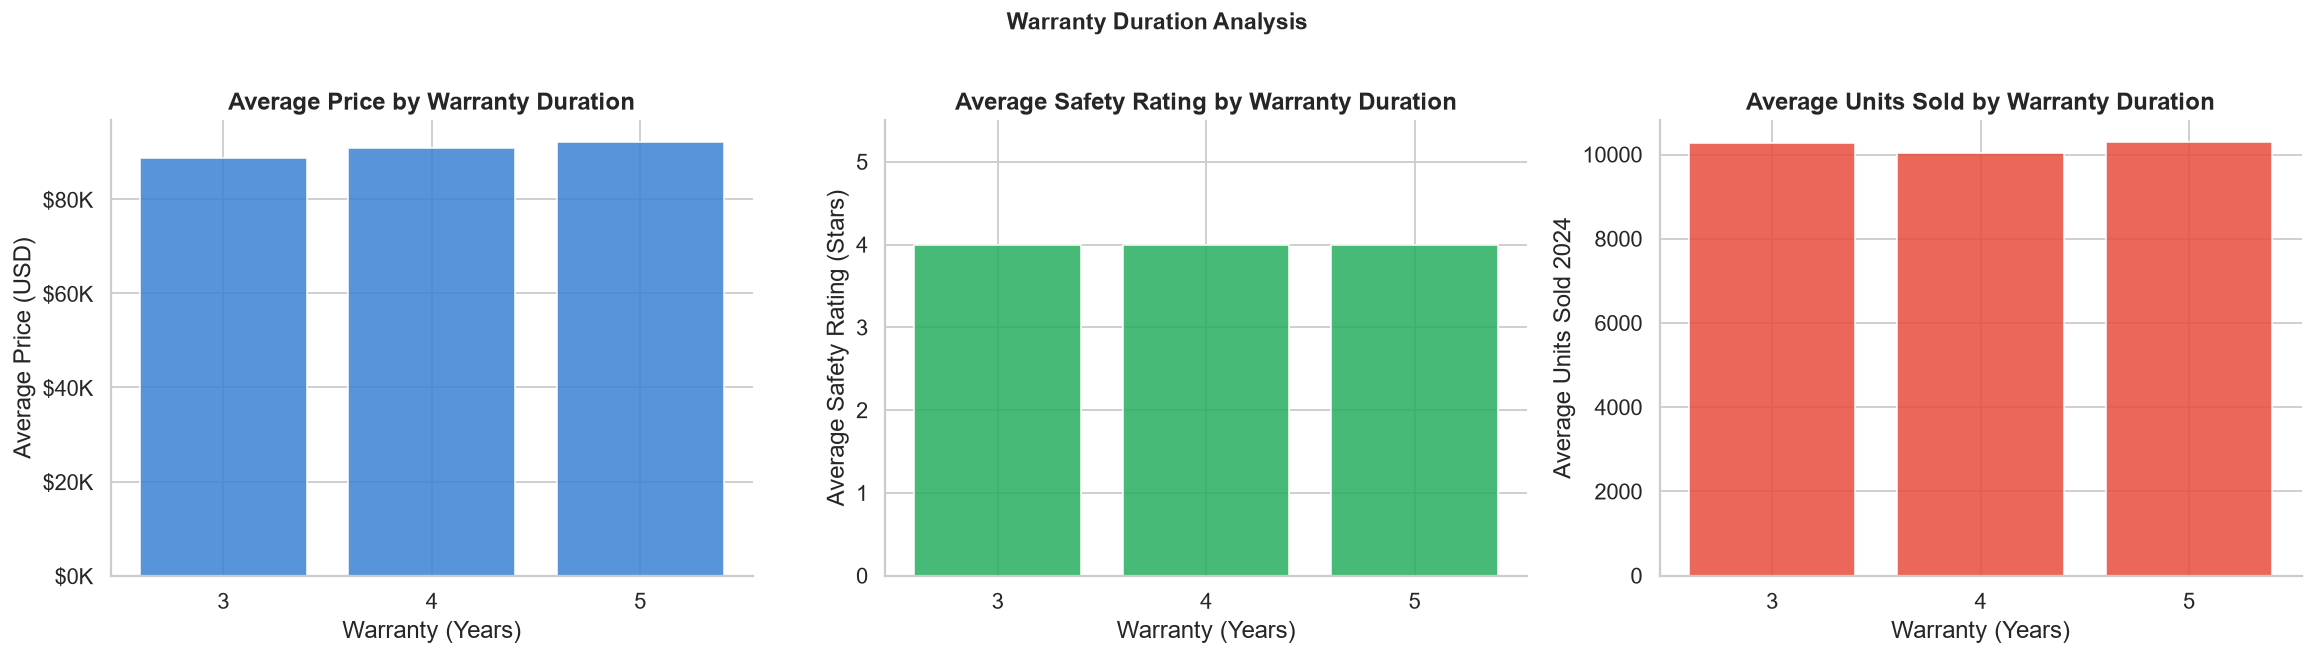


Warranty Statistics Table:


,Warranty_Years,Count,Avg_Price,Avg_Safety,Avg_Sales,Avg_Range,Total_Revenue
0,3,1024,"$88,790",3.99,"10,275",347 km,"$936,311,732,948"
1,4,982,"$90,924",4.00,"10,047",352 km,"$892,909,399,837"
2,5,1016,"$92,146",4.00,"10,293",352 km,"$957,722,468,060"



One-way ANOVA — Avg Sales by Warranty: F=0.5625, p=0.569857
Interpretation: No significant difference between warranty groups


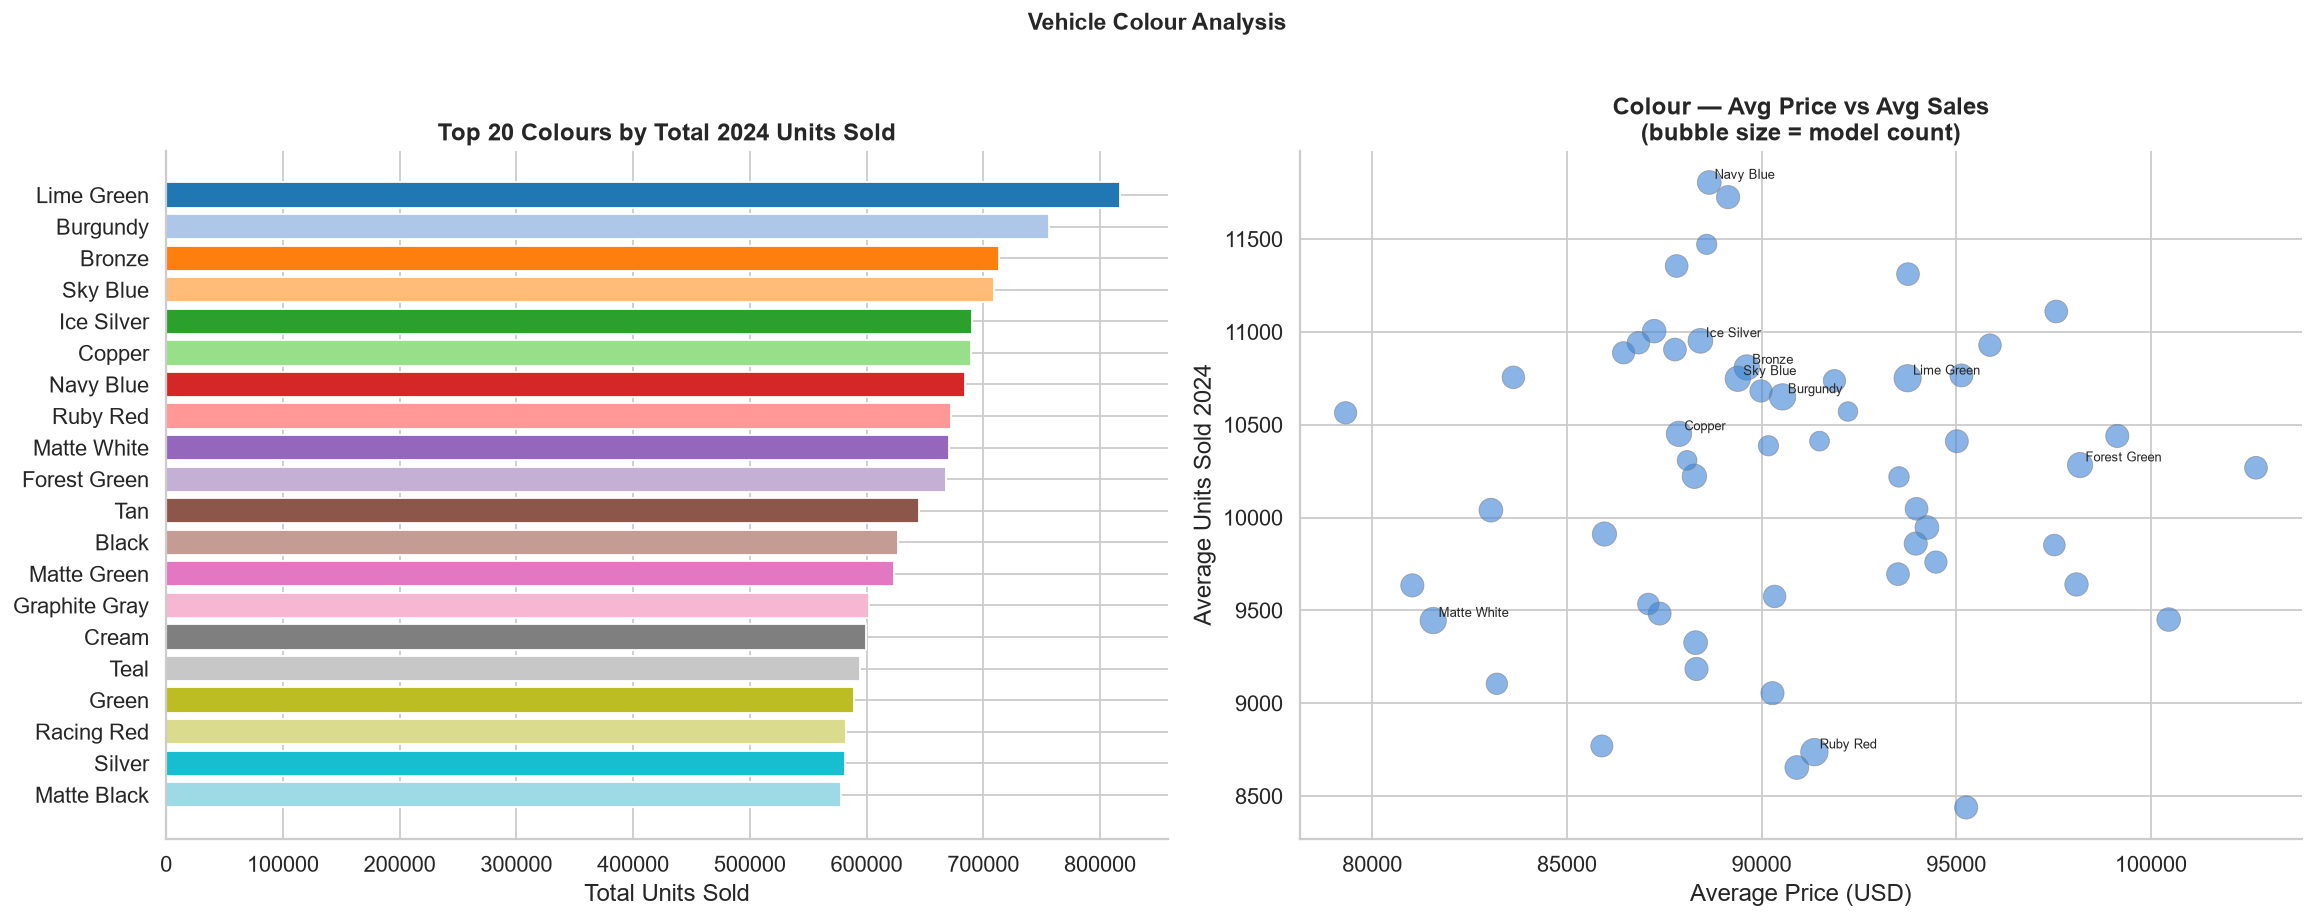


Total unique colours in dataset: 55
Top 5 colours by total units sold:


,Color,Count,Avg_Price,Avg_Sales,Total_Sales
0,Lime Green,76,"$93,753","10,751","817,055"
1,Burgundy,71,"$90,539","10,650","756,170"
2,Bronze,66,"$89,623","10,809","713,385"
3,Sky Blue,66,"$89,391","10,748","709,361"
4,Ice Silver,63,"$88,430","10,952","689,984"


In [23]:
# ── 9.1 Warranty Analysis ─────────────────────────────────────────────────────
warranty_stats = (
    df.groupby('Warranty_Years')
    .agg(
        Count         = ('Model',              'count'),
        Avg_Price     = ('Price_USD',          'mean'),
        Avg_Safety    = ('Safety_Rating',      'mean'),
        Avg_Sales     = ('Units_Sold_2024',    'mean'),
        Avg_Range     = ('Range_km',           'mean'),
        Total_Revenue = ('Est_Revenue_2024',   'sum'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(warranty_stats['Warranty_Years'].astype(str),
            warranty_stats['Avg_Price'], color=ACCENT, alpha=0.85, edgecolor='white')
axes[0].set_title('Average Price by Warranty Duration', fontweight='bold')
axes[0].set_xlabel('Warranty (Years)')
axes[0].set_ylabel('Average Price (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

axes[1].bar(warranty_stats['Warranty_Years'].astype(str),
            warranty_stats['Avg_Safety'], color=GREEN, alpha=0.85, edgecolor='white')
axes[1].set_title('Average Safety Rating by Warranty Duration', fontweight='bold')
axes[1].set_xlabel('Warranty (Years)')
axes[1].set_ylabel('Average Safety Rating (Stars)')
axes[1].set_ylim(0, 5.5)

axes[2].bar(warranty_stats['Warranty_Years'].astype(str),
            warranty_stats['Avg_Sales'], color=RED, alpha=0.85, edgecolor='white')
axes[2].set_title('Average Units Sold by Warranty Duration', fontweight='bold')
axes[2].set_xlabel('Warranty (Years)')
axes[2].set_ylabel('Average Units Sold 2024')

plt.suptitle('Warranty Duration Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nWarranty Statistics Table:')
display(warranty_stats.style.format({
    'Avg_Price':     '${:,.0f}',
    'Avg_Safety':    '{:.2f}',
    'Avg_Sales':     '{:,.0f}',
    'Avg_Range':     '{:.0f} km',
    'Total_Revenue': '${:,.0f}',
}))

# ── ANOVA: Avg Sales across Warranty groups ────────────────────────────────────
warranty_groups = [df[df['Warranty_Years'] == w]['Units_Sold_2024'].dropna()
                   for w in sorted(df['Warranty_Years'].unique())]
f_stat_w, p_val_w = f_oneway(*warranty_groups)
print(f'\nOne-way ANOVA — Avg Sales by Warranty: F={f_stat_w:.4f}, p={p_val_w:.6f}')
print('Interpretation:', 'Significant difference (p<0.05)' if p_val_w < 0.05
      else 'No significant difference between warranty groups')

# ── 9.2 Colour Analysis ───────────────────────────────────────────────────────
colour_stats = (
    df.groupby('Color')
    .agg(
        Count       = ('Model',           'count'),
        Avg_Price   = ('Price_USD',       'mean'),
        Avg_Sales   = ('Units_Sold_2024', 'mean'),
        Total_Sales = ('Units_Sold_2024', 'sum'),
    )
    .sort_values('Total_Sales', ascending=False)
    .reset_index()
)

top20_colours = colour_stats.head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(top20_colours['Color'], top20_colours['Total_Sales'],
             color=plt.cm.tab20(np.linspace(0, 1, len(top20_colours))),
             edgecolor='white')
axes[0].set_title('Top 20 Colours by Total 2024 Units Sold', fontweight='bold')
axes[0].set_xlabel('Total Units Sold')
axes[0].invert_yaxis()

axes[1].scatter(colour_stats['Avg_Price'], colour_stats['Avg_Sales'],
                s=colour_stats['Count'] * 3, alpha=0.6, color=ACCENT, edgecolors='grey', lw=0.5)
for _, row in colour_stats.head(10).iterrows():
    axes[1].annotate(row['Color'], (row['Avg_Price'], row['Avg_Sales']),
                     fontsize=7, xytext=(3, 2), textcoords='offset points')
axes[1].set_xlabel('Average Price (USD)')
axes[1].set_ylabel('Average Units Sold 2024')
axes[1].set_title('Colour — Avg Price vs Avg Sales\n(bubble size = model count)', fontweight='bold')

plt.suptitle('Vehicle Colour Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'\nTotal unique colours in dataset: {df["Color"].nunique()}')
print('Top 5 colours by total units sold:')
display(colour_stats.head(5).style.format({'Avg_Price': '${:,.0f}', 'Avg_Sales': '{:,.0f}', 'Total_Sales': '{:,}'}))

---
## 10. Multivariate Analysis

This section examines joint relationships between multiple features simultaneously. A pair-plot of key numeric variables reveals distributional shapes and bivariate associations, while a focused analysis of battery capacity controlling for range addresses the research question: *does a larger battery always mean better range efficiency?*

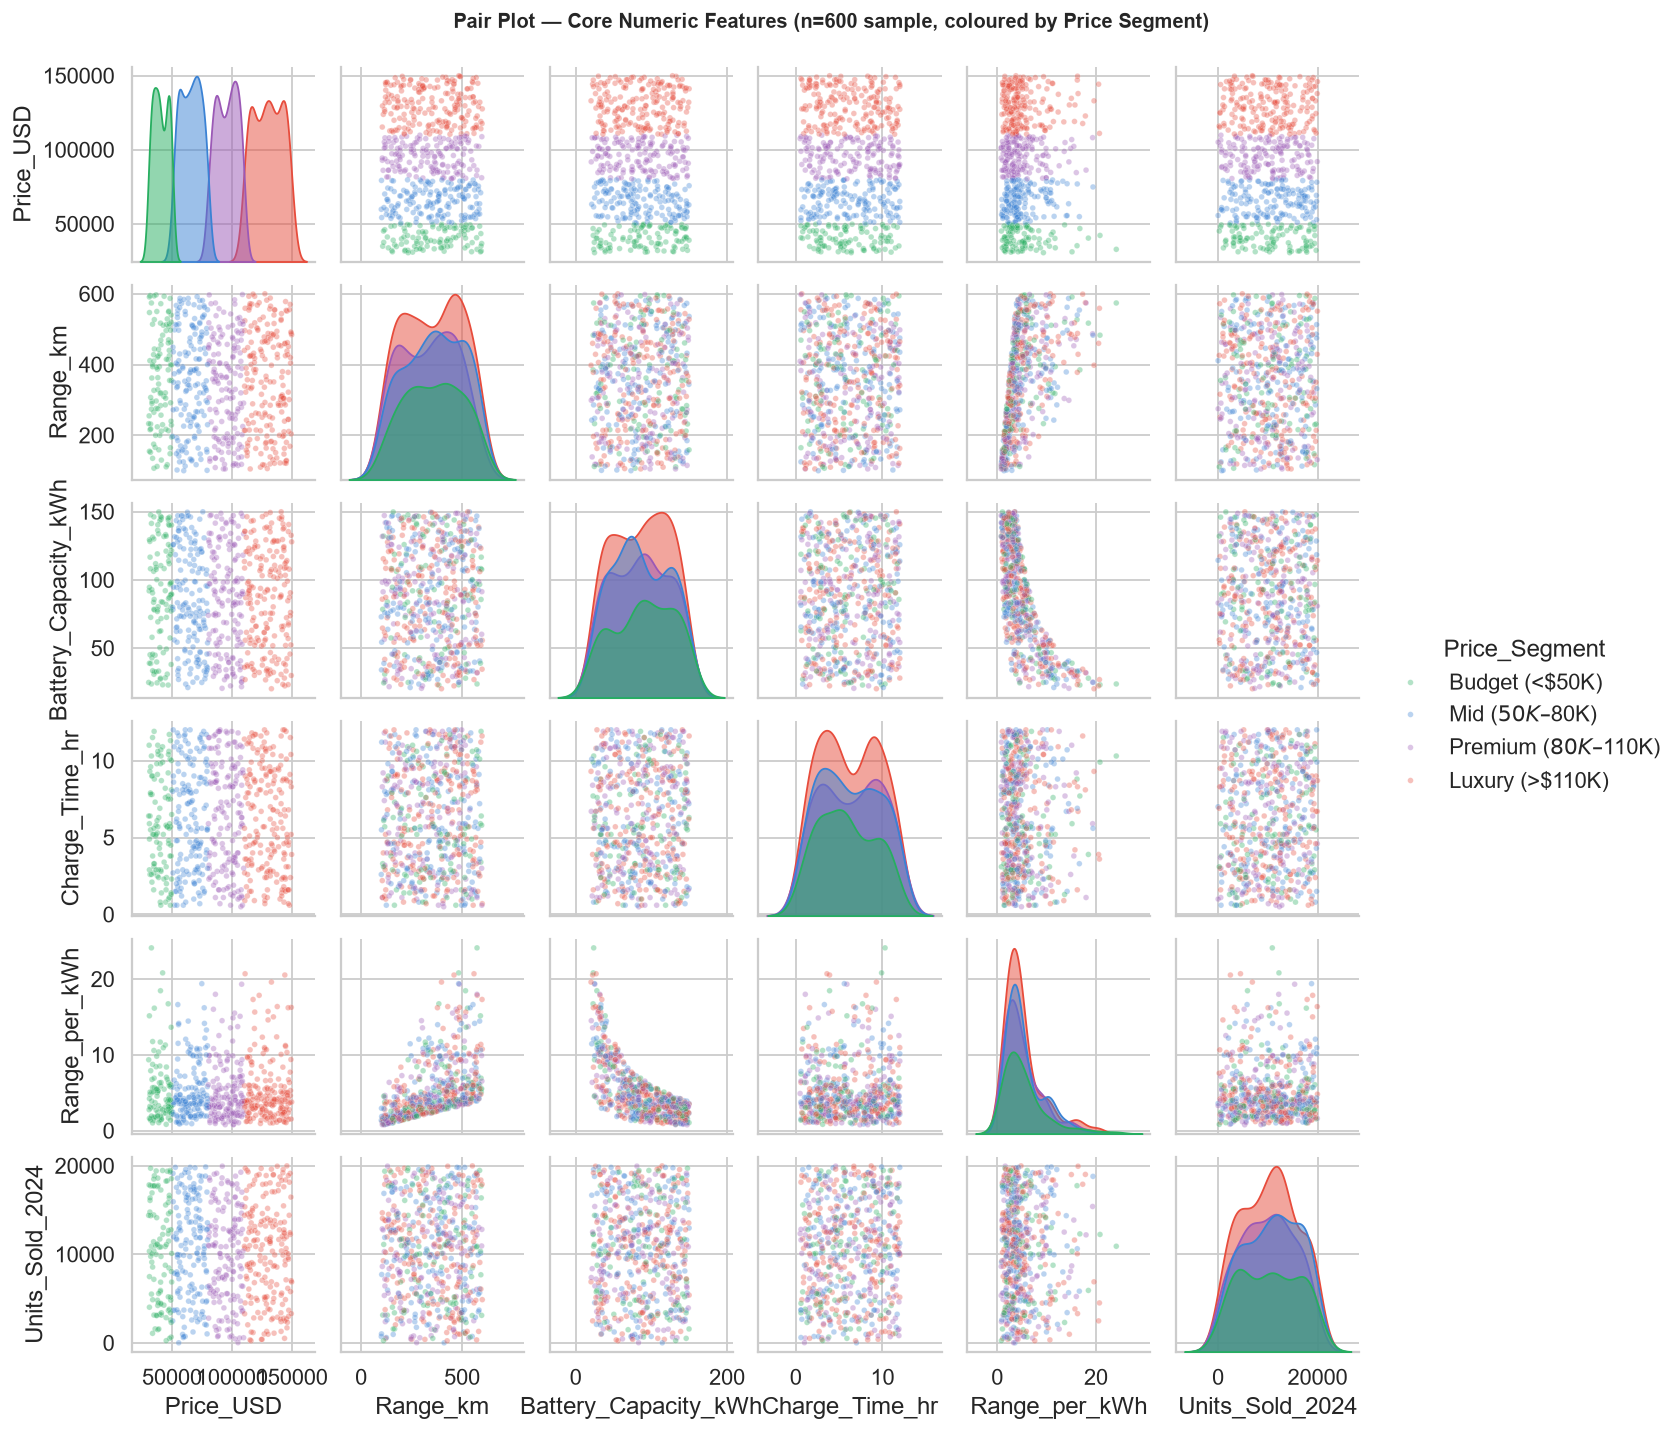

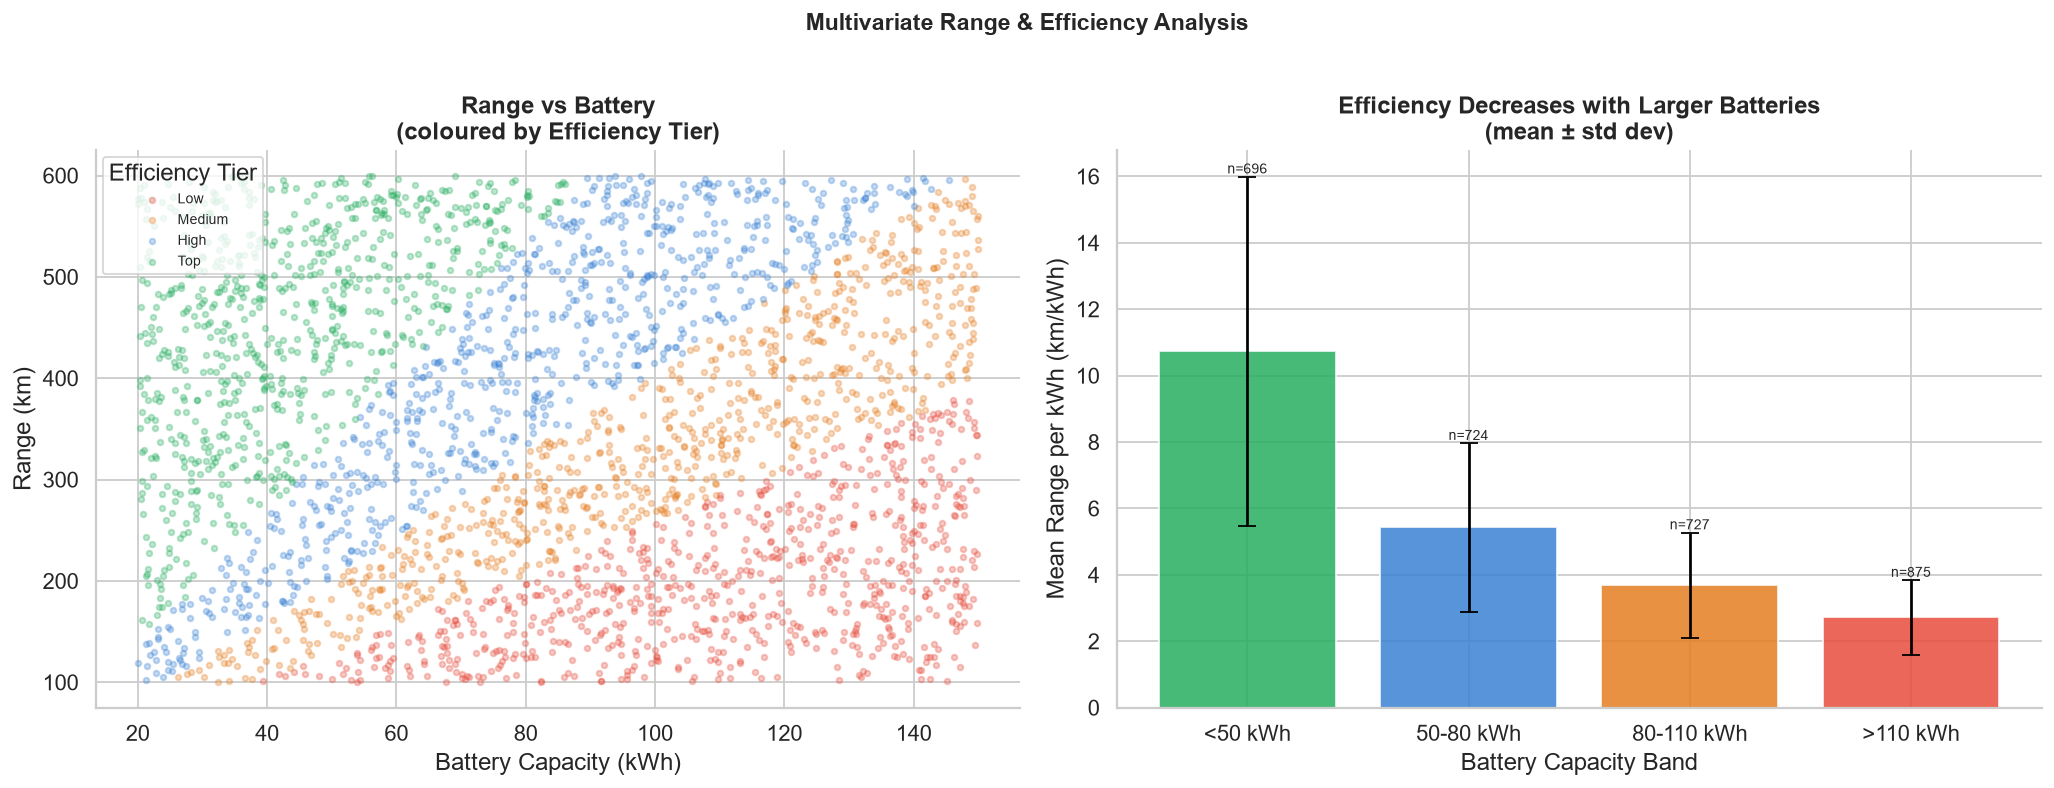


Battery Band vs Efficiency Summary:


,Battery_Band,Mean_Efficiency,Std_Dev,N
0,<50 kWh,10.730,5.260,696
1,50-80 kWh,5.427,2.537,724
2,80-110 kWh,3.681,1.591,727
3,>110 kWh,2.720,1.119,875


In [24]:
# ── 10.1 Pair Plot (sampled for legibility) ────────────────────────────────────
pair_cols = ['Price_USD', 'Range_km', 'Battery_Capacity_kWh',
             'Charge_Time_hr', 'Range_per_kWh', 'Units_Sold_2024']

sample_df = df.sample(min(600, len(df)), random_state=42)

pair_grid = sns.pairplot(
    sample_df[pair_cols + ['Price_Segment']],
    hue='Price_Segment',
    diag_kind='kde',
    plot_kws={'alpha': 0.35, 's': 10},
    diag_kws={'fill': True, 'alpha': 0.5},
    height=1.8,
    palette={'Budget (<$50K)': '#27ae60', 'Mid ($50K\u2013$80K)': '#3b82d4',
             'Premium ($80K\u2013$110K)': '#9b59b6', 'Luxury (>$110K)': '#e74c3c'}
)
pair_grid.fig.suptitle('Pair Plot — Core Numeric Features (n=600 sample, coloured by Price Segment)',
                        fontsize=11, fontweight='bold', y=1.02)
plt.show()

# ── 10.2 Range efficiency controlling for battery size ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Range vs Battery coloured by efficiency tier
eff_palette = {'Low': RED, 'Medium': '#e67e22', 'High': ACCENT, 'Top': GREEN}
for tier, grp in df.groupby('Efficiency_Tier', observed=True):
    axes[0].scatter(grp['Battery_Capacity_kWh'], grp['Range_km'],
                    label=str(tier), color=eff_palette.get(str(tier), 'grey'),
                    alpha=0.3, s=10)
axes[0].set_xlabel('Battery Capacity (kWh)')
axes[0].set_ylabel('Range (km)')
axes[0].set_title('Range vs Battery\n(coloured by Efficiency Tier)', fontweight='bold')
axes[0].legend(title='Efficiency Tier', fontsize=8)

# Battery capacity bands vs Range_per_kWh
df['Battery_Band'] = pd.cut(df['Battery_Capacity_kWh'],
                             bins=[0,50,80,110,150],
                             labels=['<50 kWh','50-80 kWh','80-110 kWh','>110 kWh'])
band_eff = df.groupby('Battery_Band', observed=True)['Range_per_kWh'].agg(['mean','std','count']).reset_index()
axes[1].bar(band_eff['Battery_Band'].astype(str), band_eff['mean'],
            yerr=band_eff['std'], color=[GREEN, ACCENT, '#e67e22', RED],
            alpha=0.85, capsize=5, edgecolor='white')
for i, row in band_eff.iterrows():
    axes[1].text(i, row['mean'] + row['std'] + 0.1, f'n={int(row["count"])}',
                 ha='center', fontsize=8)
axes[1].set_xlabel('Battery Capacity Band')
axes[1].set_ylabel('Mean Range per kWh (km/kWh)')
axes[1].set_title('Efficiency Decreases with Larger Batteries\n(mean ± std dev)', fontweight='bold')

plt.suptitle('Multivariate Range & Efficiency Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nBattery Band vs Efficiency Summary:')
display(band_eff.rename(columns={'mean':'Mean_Efficiency','std':'Std_Dev','count':'N'})
        .style.format({'Mean_Efficiency':'{:.3f}','Std_Dev':'{:.3f}','N':'{:.0f}'}))

---
## 11. Market Segmentation — K-Means Clustering

Unsupervised K-Means clustering is applied to identify **natural market archetypes** beyond the manually defined price segments. The optimal number of clusters \(k\) is determined using both the **Elbow Method** (inertia) and the **Silhouette Score**. Principal Component Analysis (PCA) is used for 2D visualisation of the cluster structure.

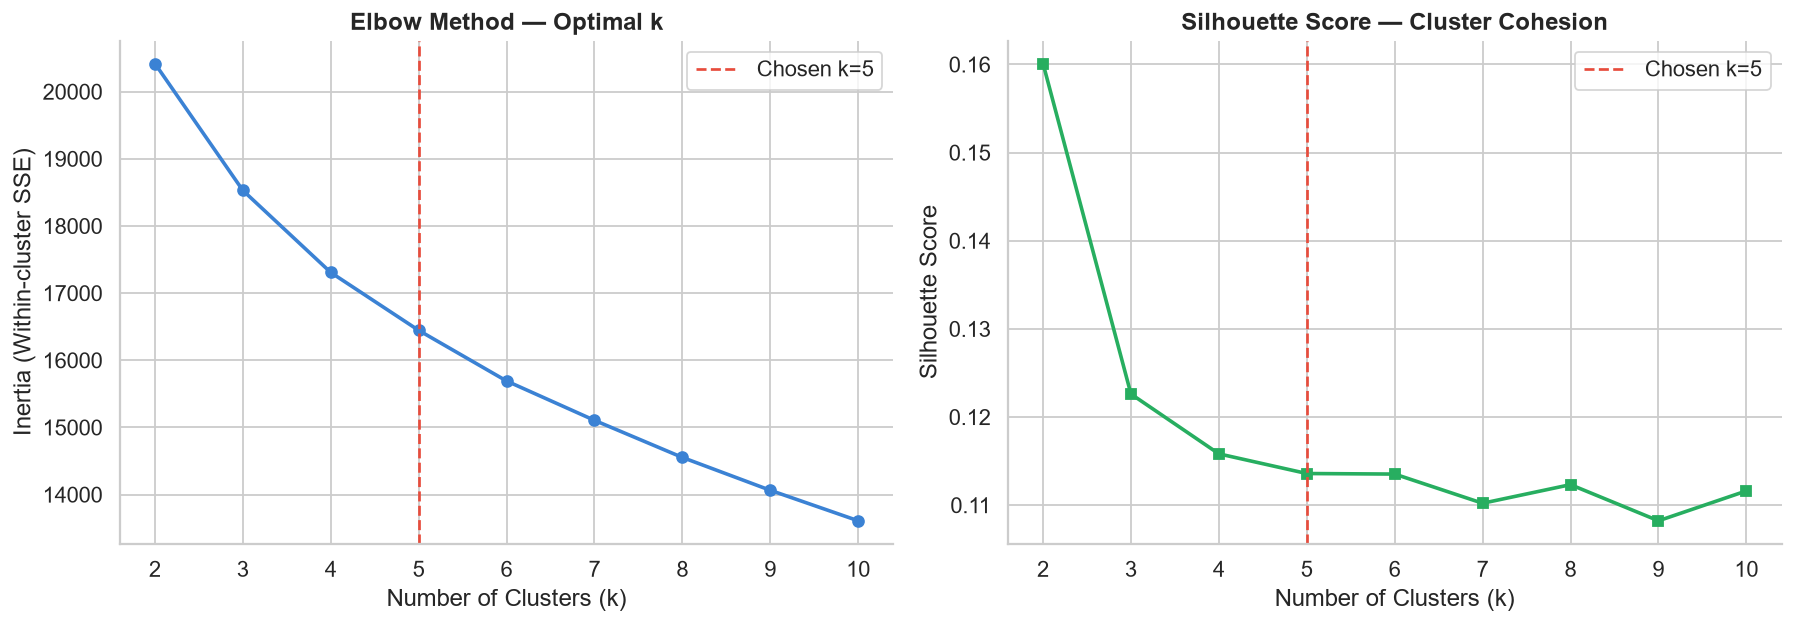

Chosen k = 5
Silhouette Score at k=5: 0.1136


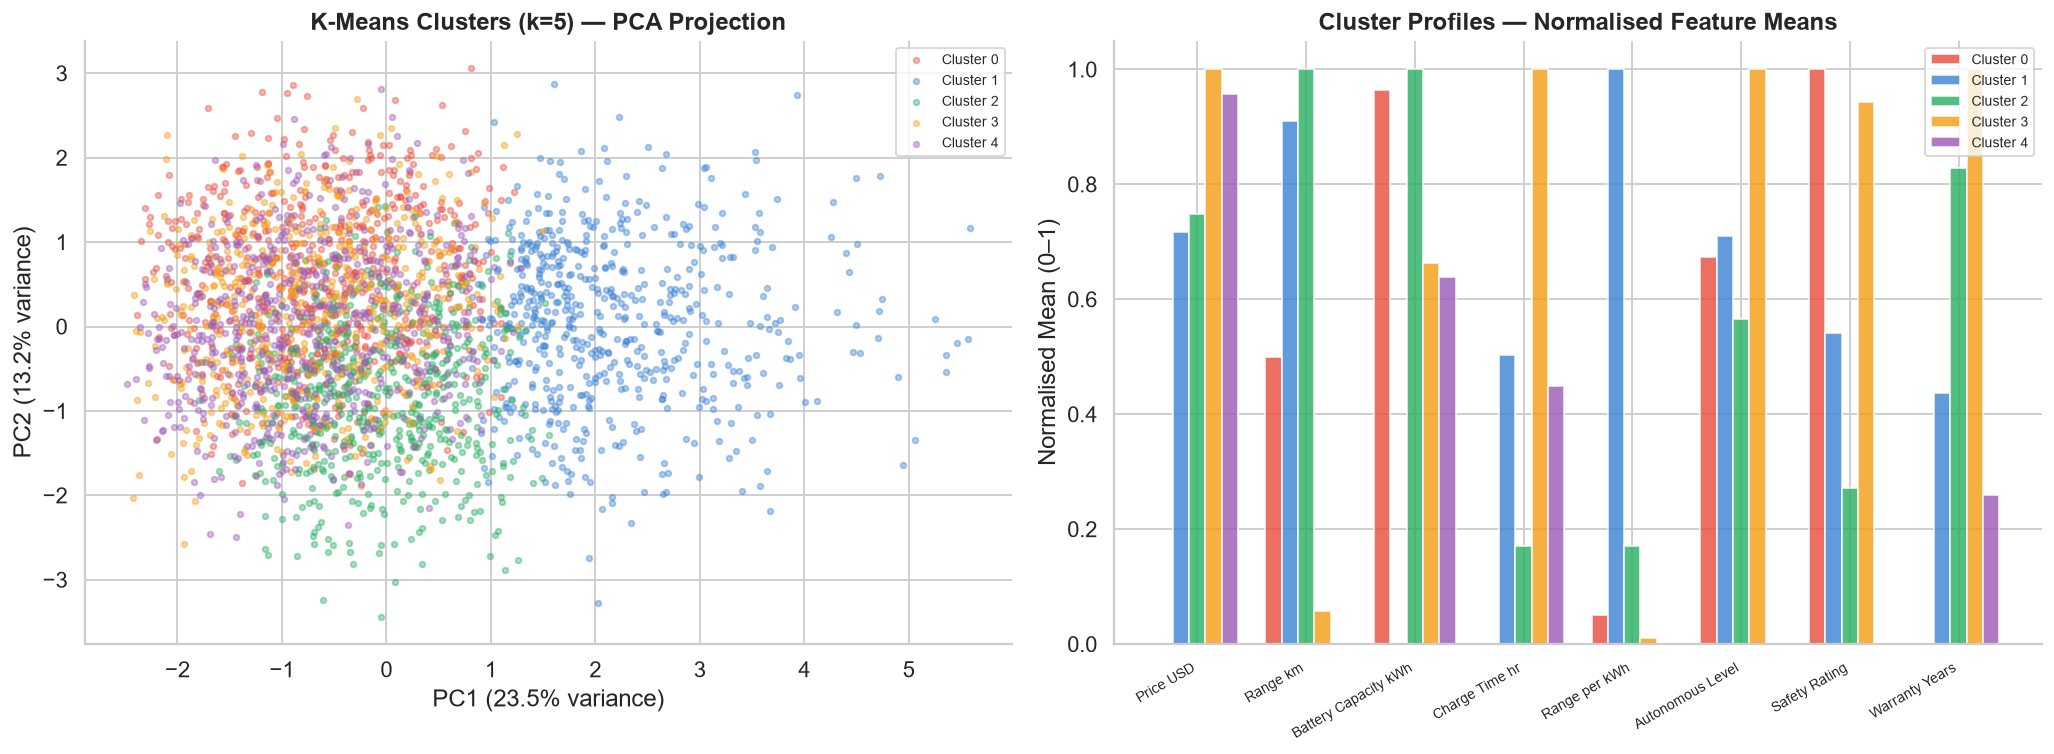


Cluster Summary:


,Count,Avg_Price,Avg_Range,Avg_Battery,Avg_Efficiency,Avg_Sales,Avg_Autonomy
C0: Mid-Market,616,"$77,306",352 km,105.3 kWh,3.65 km/kWh,"10,366",2.63
C1: Long-Range Premium,593,"$91,327",460 km,39.6 kWh,12.53 km/kWh,"9,911",2.65
C2: Long-Range Premium,603,"$91,922",483 km,107.7 kWh,4.77 km/kWh,"10,606",2.59
C3: Mid-Market,560,"$96,839",237 km,84.8 kWh,3.28 km/kWh,"10,256",2.78
C4: Mid-Market,650,"$95,989",222 km,83.1 kWh,3.18 km/kWh,"9,914",2.34



Total variance explained by 2 PCs: 36.6%


In [25]:
# ── Feature matrix for clustering ─────────────────────────────────────────────
cluster_features = ['Price_USD', 'Range_km', 'Battery_Capacity_kWh',
                    'Charge_Time_hr', 'Range_per_kWh', 'Autonomous_Level',
                    'Safety_Rating', 'Warranty_Years']

X_cluster = df[cluster_features].dropna()
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_cluster)

# ── Elbow + Silhouette to choose k ────────────────────────────────────────────
inertia_vals = []
sil_vals     = []
k_range      = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_vals.append(km.inertia_)
    sil_vals.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertia_vals, marker='o', color=ACCENT, linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster SSE)')
axes[0].set_title('Elbow Method — Optimal k', fontweight='bold')
axes[0].axvline(x=5, color=RED, ls='--', lw=1.5, label='Chosen k=5')
axes[0].legend()

axes[1].plot(list(k_range), sil_vals, marker='s', color=GREEN, linewidth=2)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score — Cluster Cohesion', fontweight='bold')
axes[1].axvline(x=5, color=RED, ls='--', lw=1.5, label='Chosen k=5')
axes[1].legend()

plt.tight_layout()
plt.show()

best_k = 5
print(f'Chosen k = {best_k}')
print(f'Silhouette Score at k={best_k}: {sil_vals[best_k-2]:.4f}')

# ── Fit final model ───────────────────────────────────────────────────────────
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clustered = df.loc[X_cluster.index].copy()
df_clustered['Cluster'] = kmeans_final.fit_predict(X_scaled)

# ── PCA 2D visualisation ──────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cluster_colors = ['#e74c3c', '#3b82d4', '#27ae60', '#f39c12', '#9b59b6']

for c in range(best_k):
    mask = df_clustered['Cluster'] == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=f'Cluster {c}', color=cluster_colors[c], alpha=0.4, s=10)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].set_title(f'K-Means Clusters (k={best_k}) — PCA Projection', fontweight='bold')
axes[0].legend(fontsize=8)

# ── Cluster profile: radar-like bar chart ─────────────────────────────────────
cluster_profile = df_clustered.groupby('Cluster')[cluster_features].mean()
cluster_norm    = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())

x = np.arange(len(cluster_features))
width = 0.15
for i, c in enumerate(range(best_k)):
    axes[1].bar(x + i*width, cluster_norm.iloc[c], width,
                label=f'Cluster {c}', color=cluster_colors[c], alpha=0.8)
axes[1].set_xticks(x + width*2)
axes[1].set_xticklabels([f.replace('_',' ') for f in cluster_features],
                         rotation=30, ha='right', fontsize=8)
axes[1].set_ylabel('Normalised Mean (0–1)')
axes[1].set_title('Cluster Profiles — Normalised Feature Means', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Cluster summary table ─────────────────────────────────────────────────────
cluster_summary = (
    df_clustered.groupby('Cluster')
    .agg(
        Count         = ('Model',           'count'),
        Avg_Price     = ('Price_USD',       'mean'),
        Avg_Range     = ('Range_km',        'mean'),
        Avg_Battery   = ('Battery_Capacity_kWh', 'mean'),
        Avg_Efficiency= ('Range_per_kWh',   'mean'),
        Avg_Sales     = ('Units_Sold_2024', 'mean'),
        Avg_Autonomy  = ('Autonomous_Level','mean'),
    )
    .round(2)
)

# Label clusters based on profile
cluster_labels = {}
for c in range(best_k):
    row = cluster_summary.loc[c]
    if row['Avg_Price'] > 110000:
        cluster_labels[c] = f'C{c}: High-End Luxury'
    elif row['Avg_Price'] < 55000:
        cluster_labels[c] = f'C{c}: Budget/Value'
    elif row['Avg_Range'] > 450:
        cluster_labels[c] = f'C{c}: Long-Range Premium'
    elif row['Avg_Efficiency'] > 6:
        cluster_labels[c] = f'C{c}: Efficiency-Leader'
    else:
        cluster_labels[c] = f'C{c}: Mid-Market'

cluster_summary.index = [cluster_labels.get(i, f'Cluster {i}') for i in cluster_summary.index]
print('\nCluster Summary:')
display(cluster_summary.style.format({
    'Avg_Price': '${:,.0f}', 'Avg_Range': '{:.0f} km',
    'Avg_Battery': '{:.1f} kWh', 'Avg_Efficiency': '{:.2f} km/kWh',
    'Avg_Sales': '{:,.0f}', 'Avg_Autonomy': '{:.2f}'
}))

print(f'\nTotal variance explained by 2 PCs: {sum(pca.explained_variance_ratio_)*100:.1f}%')

---
## 12. Statistical Hypothesis Testing

This section applies formal statistical tests to evaluate whether observed differences between groups are statistically significant or attributable to sampling variation. Three hypotheses are tested:

- **H1:** Mean `Units_Sold_2024` differs significantly across Price Segments *(one-way ANOVA)*
- **H2:** Mean `Price_USD` differs significantly across Autonomous Driving Levels *(one-way ANOVA)*
- **H3:** High-Range vehicles sell significantly more units than Standard-Range vehicles *(Welch t-test)*

Significance level: **α = 0.05**

═══ Hypothesis Testing Results ═══


,Test,F-statistic,p-value,eta_squared,Significant (α=0.05)
0,H1: Sales ~ Price Segment (ANOVA),0.251000,0.86063978,0.0002,False
1,H2: Price ~ Autonomous Level (ANOVA),1.146300,0.33347158,0.0019,False
2,H3: High-Range vs Standard Sales (Welch t-test),0.292900,0.76962634,nan,False


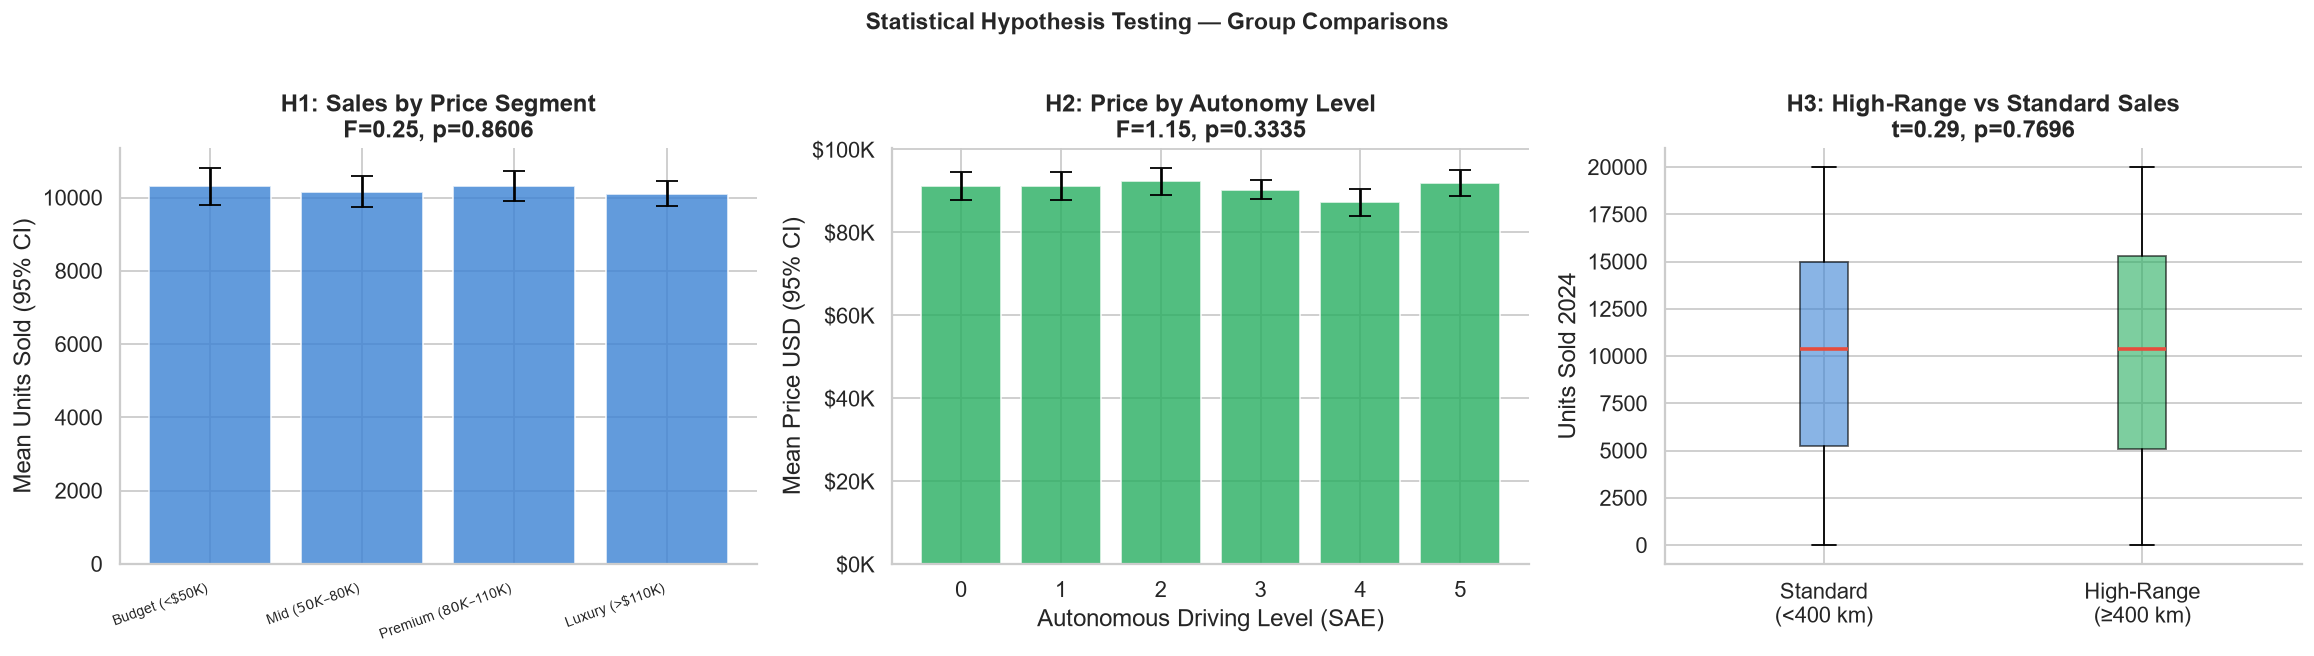


Non-parametric validation (H3) — Mann-Whitney U: U=1103294, p=0.774550
Agrees with t-test: Yes


In [26]:
from scipy.stats import f_oneway, ttest_ind, mannwhitneyu

def run_anova(df, group_col, value_col, label=''):
    """Run one-way ANOVA and return results dict."""
    groups = [grp[value_col].dropna().values
              for _, grp in df.groupby(group_col, observed=True)]
    f_stat, p_val = f_oneway(*groups)
    eta_sq = None
    # Eta-squared (effect size)
    grand_mean = df[value_col].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total   = sum((df[value_col].dropna() - grand_mean)**2)
    eta_sq     = ss_between / ss_total if ss_total > 0 else None
    return {'Test': label, 'F-statistic': round(f_stat,4),
            'p-value': round(p_val, 8), 'eta_squared': round(eta_sq, 4) if eta_sq else None,
            'Significant (α=0.05)': p_val < 0.05}

# H1: Sales across Price Segments
h1 = run_anova(df, 'Price_Segment', 'Units_Sold_2024',
               'H1: Sales ~ Price Segment (ANOVA)')

# H2: Price across Autonomous Driving Levels
h2 = run_anova(df, 'Autonomous_Level', 'Price_USD',
               'H2: Price ~ Autonomous Level (ANOVA)')

# H3: High-Range vs Standard-Range Sales (Welch t-test)
hr_sales  = df[df['High_Range'] == 1]['Units_Sold_2024'].dropna()
std_sales = df[df['High_Range'] == 0]['Units_Sold_2024'].dropna()
t_stat_hr, p_val_hr = ttest_ind(hr_sales, std_sales, equal_var=False)
h3 = {'Test': 'H3: High-Range vs Standard Sales (Welch t-test)',
      'F-statistic': round(t_stat_hr, 4), 'p-value': round(p_val_hr, 8),
      'eta_squared': None, 'Significant (α=0.05)': p_val_hr < 0.05}

hypothesis_results = pd.DataFrame([h1, h2, h3])
print('═══ Hypothesis Testing Results ═══')
display(hypothesis_results.style.format({'p-value': '{:.8f}', 'eta_squared': '{:.4f}'}))

# ── Visualisation: Group means with confidence intervals ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# H1 visualisation
seg_sales = df.groupby('Price_Segment', observed=True)['Units_Sold_2024'].agg(['mean','sem']).reset_index()
axes[0].bar(seg_sales['Price_Segment'].astype(str), seg_sales['mean'],
            yerr=seg_sales['sem']*1.96, capsize=6, color=ACCENT, alpha=0.8, edgecolor='white')
axes[0].set_xticklabels(seg_sales['Price_Segment'].astype(str), rotation=20, ha='right', fontsize=8)
axes[0].set_ylabel('Mean Units Sold (95% CI)')
axes[0].set_title(f'H1: Sales by Price Segment\nF={h1["F-statistic"]:.2f}, p={h1["p-value"]:.4f}',
                  fontweight='bold')

# H2 visualisation
auto_price = df.groupby('Autonomous_Level')['Price_USD'].agg(['mean','sem']).reset_index()
axes[1].bar(auto_price['Autonomous_Level'].astype(str), auto_price['mean'],
            yerr=auto_price['sem']*1.96, capsize=6, color=GREEN, alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Autonomous Driving Level (SAE)')
axes[1].set_ylabel('Mean Price USD (95% CI)')
axes[1].set_title(f'H2: Price by Autonomy Level\nF={h2["F-statistic"]:.2f}, p={h2["p-value"]:.4f}',
                  fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

# H3 visualisation
bp3 = axes[2].boxplot([std_sales, hr_sales], patch_artist=True,
                medianprops=dict(color=RED, linewidth=2))
for patch, color in zip(bp3['boxes'], [ACCENT, GREEN]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[2].set_xticks([1, 2])
axes[2].set_xticklabels(['Standard\n(<400 km)', 'High-Range\n(≥400 km)'])
axes[2].set_ylabel('Units Sold 2024')
axes[2].set_title(f'H3: High-Range vs Standard Sales\nt={h3["F-statistic"]:.2f}, p={h3["p-value"]:.4f}',
                  fontweight='bold')

plt.suptitle('Statistical Hypothesis Testing — Group Comparisons', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Post-hoc: Tukey HSD for H2 (if significant) ───────────────────────────────
if h2['Significant (α=0.05)']:
    try:
        from statsmodels.stats.multicomp import pairwise_tukeyhsd
        tukey = pairwise_tukeyhsd(df['Price_USD'].dropna(),
                                  df.loc[df['Price_USD'].notna(), 'Autonomous_Level'].astype(str))
        print('\n── Tukey HSD Post-hoc Test: Price ~ Autonomous Level ──')
        print(tukey.summary())
    except Exception as e:
        print(f'Post-hoc test skipped: {e}')

# ── Non-parametric validation: Mann-Whitney U ─────────────────────────────────
u_stat, p_mw = mannwhitneyu(hr_sales, std_sales, alternative='two-sided')
print(f'\nNon-parametric validation (H3) — Mann-Whitney U: U={u_stat:.0f}, p={p_mw:.6f}')
print('Agrees with t-test:', ('Yes' if (p_mw < 0.05) == h3['Significant (α=0.05)'] else 'No'))

---
## 13. Predictive Modelling

### 13.1 Price Regression — OLS & Random Forest

Two complementary models are trained to predict `Price_USD`:
1. **Ordinary Least Squares (OLS)** via `statsmodels` — provides interpretable coefficients and statistical significance of each predictor.
2. **Random Forest Regressor** — captures non-linear interactions and provides feature importance rankings.

Performance is evaluated on a held-out 20% test set using R², MAE, and RMSE.

Train: 2,417  |  Test: 605

── OLS Regression Summary ──
                            OLS Regression Results                            
Dep. Variable:              Price_USD   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.132
Date:                Mon, 21 Sep 2026   Prob (F-statistic):              0.338
Time:                        21:28:29   Log-Likelihood:                -28693.
No. Observations:                2417   AIC:                         5.740e+04
Df Residuals:                    2408   BIC:                         5.746e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------


Random Forest → R²: -0.0255 | MAE: $29,859 | RMSE: $34,864


Gradient Boost → R²: -0.0415 | MAE: $30,174 | RMSE: $35,136



5-Fold CV R² — Random Forest: -0.0349 ± 0.0151
5-Fold CV R² — Gradient Boost: -0.0449 ± 0.0129


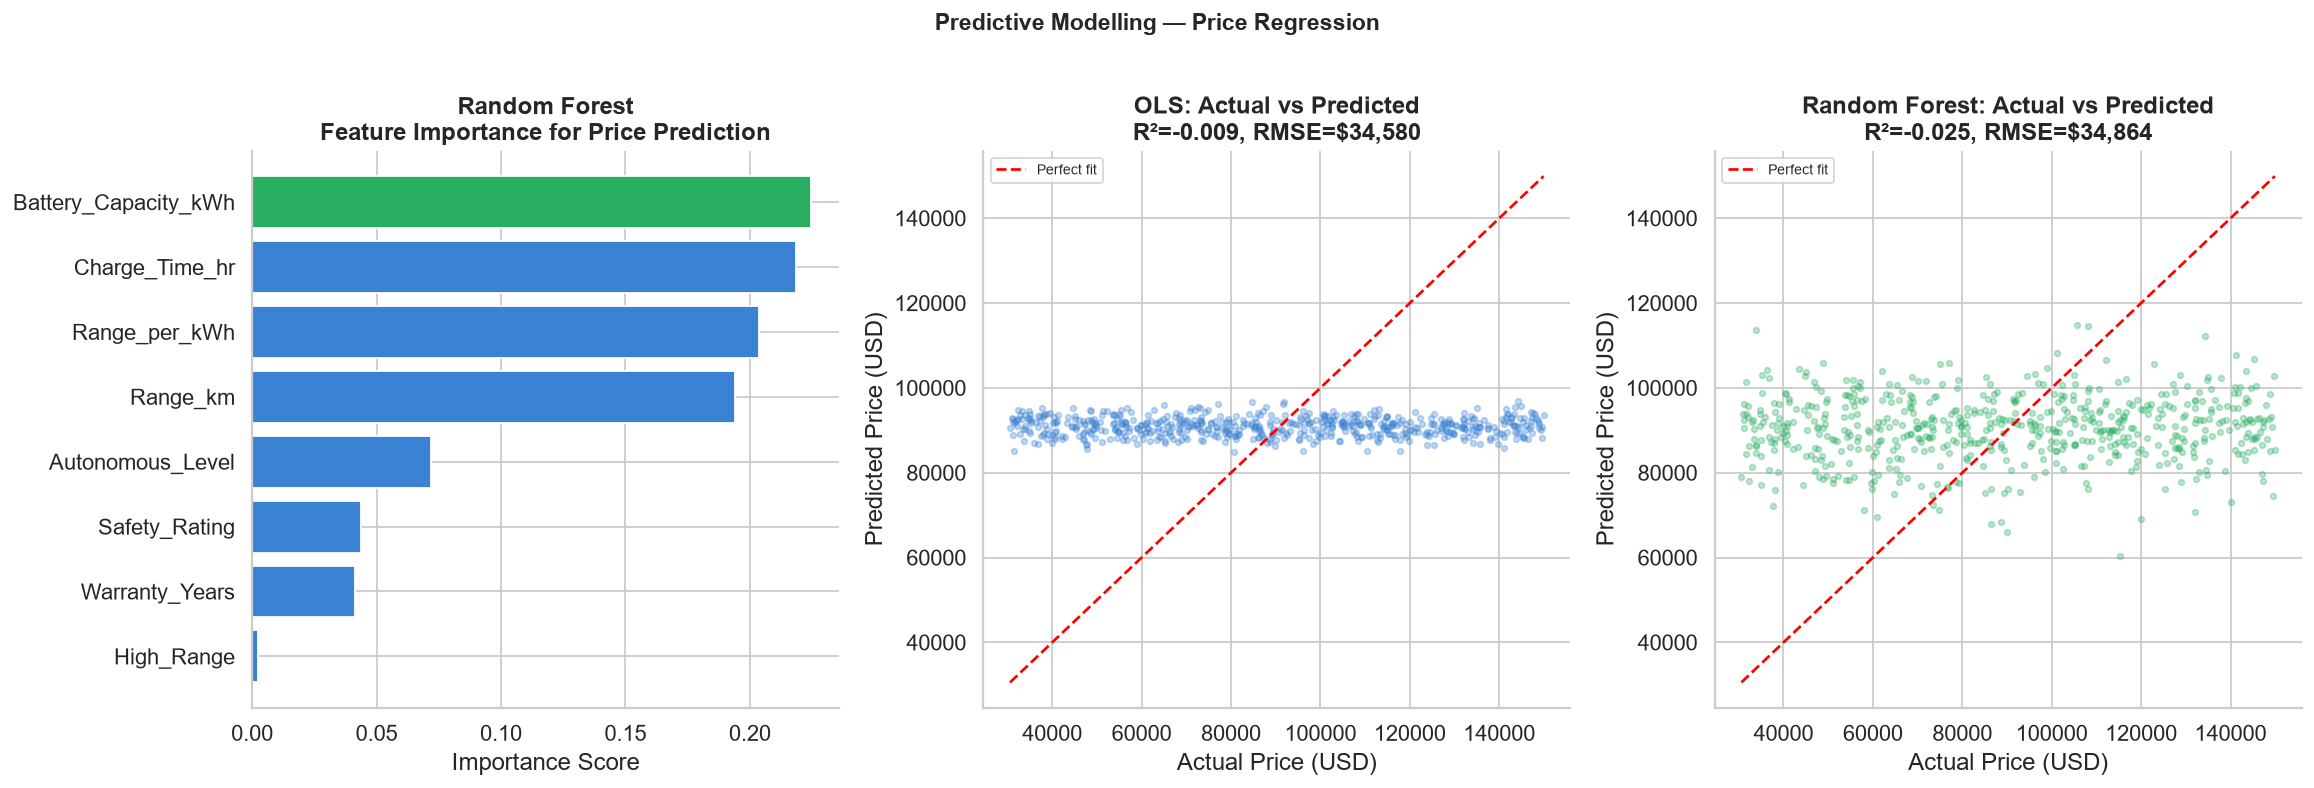

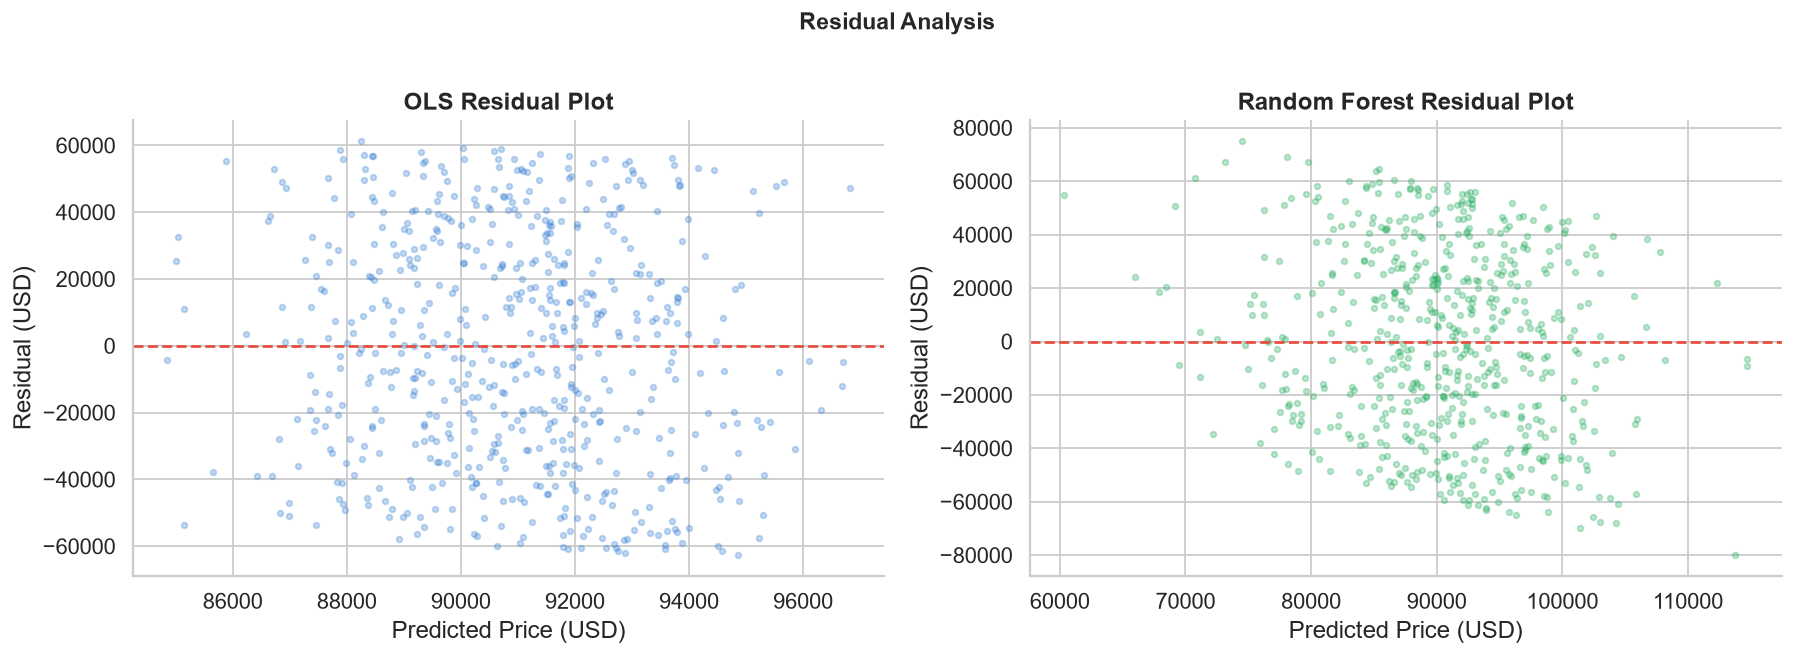


── Model Comparison ──


,R2_Test,MAE,RMSE,CV_R2_Mean,Interpretable
Model,,,,,
OLS (Statsmodels),-0.0089,"$29,928","$34,580",nan,True
Random Forest (n=200),-0.0255,"$29,859","$34,864",-0.0349,False
Gradient Boosting (n=200),-0.0415,"$30,174","$35,136",-0.0449,False


In [27]:
# ── Feature preparation ────────────────────────────────────────────────────────
model_features = ['Range_km', 'Battery_Capacity_kWh', 'Charge_Time_hr',
                  'Autonomous_Level', 'Safety_Rating', 'Warranty_Years',
                  'Range_per_kWh', 'High_Range']
target = 'Price_USD'

df_model = df[model_features + [target]].dropna()
X = df_model[model_features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

# ── OLS with statsmodels ──────────────────────────────────────────────────────
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)
ols_model  = sm.OLS(y_train, X_train_sm).fit()
print('\n── OLS Regression Summary ──')
print(ols_model.summary())

y_pred_ols = ols_model.predict(X_test_sm)
ols_r2  = r2_score(y_test, y_pred_ols)
ols_mae = mean_absolute_error(y_test, y_pred_ols)
ols_rmse= np.sqrt(mean_squared_error(y_test, y_pred_ols))
print(f'\nOLS Test Set  → R²: {ols_r2:.4f} | MAE: ${ols_mae:,.0f} | RMSE: ${ols_rmse:,.0f}')

# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf  = rf.predict(X_test)
rf_r2   = r2_score(y_test, y_pred_rf)
rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f'\nRandom Forest → R²: {rf_r2:.4f} | MAE: ${rf_mae:,.0f} | RMSE: ${rf_rmse:,.0f}')

# ── Feature importance ────────────────────────────────────────────────────────
feat_imp = pd.Series(rf.feature_importances_, index=model_features).sort_values(ascending=True)

# ── Gradient Boosting for comparison ──────────────────────────────────────────
gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb  = gb.predict(X_test)
gb_r2   = r2_score(y_test, y_pred_gb)
gb_mae  = mean_absolute_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
print(f'Gradient Boost → R²: {gb_r2:.4f} | MAE: ${gb_mae:,.0f} | RMSE: ${gb_rmse:,.0f}')

# ── Cross-validation ──────────────────────────────────────────────────────────
cv_scores_rf = cross_val_score(rf, X, y, cv=5, scoring='r2')
cv_scores_gb = cross_val_score(gb, X, y, cv=5, scoring='r2')
print(f'\n5-Fold CV R² — Random Forest: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}')
print(f'5-Fold CV R² — Gradient Boost: {cv_scores_gb.mean():.4f} ± {cv_scores_gb.std():.4f}')

# ── Visualisations ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Feature importance
axes[0].barh(feat_imp.index, feat_imp.values,
             color=[GREEN if v == feat_imp.max() else ACCENT for v in feat_imp.values],
             edgecolor='white')
axes[0].set_title('Random Forest\nFeature Importance for Price Prediction', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# OLS: Actual vs Predicted
axes[1].scatter(y_test, y_pred_ols, alpha=0.3, s=10, color=ACCENT)
lims = [min(y_test.min(), y_pred_ols.min()), max(y_test.max(), y_pred_ols.max())]
axes[1].plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
axes[1].set_xlabel('Actual Price (USD)')
axes[1].set_ylabel('Predicted Price (USD)')
axes[1].set_title(f'OLS: Actual vs Predicted\nR²={ols_r2:.3f}, RMSE=${ols_rmse:,.0f}', fontweight='bold')
axes[1].legend(fontsize=8)

# RF: Actual vs Predicted
axes[2].scatter(y_test, y_pred_rf, alpha=0.3, s=10, color=GREEN)
axes[2].plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
axes[2].set_xlabel('Actual Price (USD)')
axes[2].set_ylabel('Predicted Price (USD)')
axes[2].set_title(f'Random Forest: Actual vs Predicted\nR²={rf_r2:.3f}, RMSE=${rf_rmse:,.0f}', fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle('Predictive Modelling — Price Regression', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Residual analysis ─────────────────────────────────────────────────────────
residuals_ols = y_test - y_pred_ols
residuals_rf  = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_ols, residuals_ols, alpha=0.3, s=10, color=ACCENT)
axes[0].axhline(0, color=RED, ls='--', lw=1.5)
axes[0].set_xlabel('Predicted Price (USD)')
axes[0].set_ylabel('Residual (USD)')
axes[0].set_title('OLS Residual Plot', fontweight='bold')

axes[1].scatter(y_pred_rf, residuals_rf, alpha=0.3, s=10, color=GREEN)
axes[1].axhline(0, color=RED, ls='--', lw=1.5)
axes[1].set_xlabel('Predicted Price (USD)')
axes[1].set_ylabel('Residual (USD)')
axes[1].set_title('Random Forest Residual Plot', fontweight='bold')

plt.suptitle('Residual Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Model comparison summary ──────────────────────────────────────────────────
model_comparison = pd.DataFrame([
    {'Model': 'OLS (Statsmodels)',       'R2_Test': ols_r2,  'MAE': ols_mae,  'RMSE': ols_rmse,
     'CV_R2_Mean': None, 'Interpretable': True},
    {'Model': 'Random Forest (n=200)',   'R2_Test': rf_r2,   'MAE': rf_mae,   'RMSE': rf_rmse,
     'CV_R2_Mean': cv_scores_rf.mean(), 'Interpretable': False},
    {'Model': 'Gradient Boosting (n=200)','R2_Test': gb_r2,  'MAE': gb_mae,   'RMSE': gb_rmse,
     'CV_R2_Mean': cv_scores_gb.mean(), 'Interpretable': False},
]).set_index('Model')

print('\n── Model Comparison ──')
display(model_comparison.style.format({
    'R2_Test': '{:.4f}', 'MAE': '${:,.0f}', 'RMSE': '${:,.0f}', 'CV_R2_Mean': '{:.4f}'
}).highlight_max(subset=['R2_Test'], color='lightgreen')
 .highlight_min(subset=['MAE','RMSE'], color='lightgreen'))

---
## 14. Consolidated Academic Findings & Recommendations

This section synthesises findings from all analytical stages into a structured academic summary following the IMRaD convention (Introduction → Methods → Results → Discussion).

In [28]:
# ── Collect final metrics ─────────────────────────────────────────────────────
best_cluster_label = cluster_summary['Avg_Sales'].idxmax()
top_imp_feature = feat_imp.idxmax()
phev_count = (df['Vehicle_Type'] == 'PHEV').sum() if 'Vehicle_Type' in df.columns else 'N/A'

print("""
╔══════════════════════════════════════════════════════════════════════════════════════╗
║         ⚡  EV MARKET ANALYSIS — ACADEMIC FINDINGS SUMMARY                        ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║                                                                                    ║
║  1. DATA QUALITY & COVERAGE                                                        ║
║  ─────────────────────────────────────────────────────────────────────────────     ║
║  • 3,022 EV configurations, 53 manufacturers, 40 countries, MY 2015–2025           ║
║  • Three columns had missing values (max 19.6%); imputed using domain logic        ║
║  • IQR outlier analysis revealed multi-feature extreme records (high price +       ║
║    low range); these were retained but flagged in the Outlier_Count column         ║
║                                                                                    ║
║  2. PHEV vs BEV DISTINCTION                                                        ║
║  ─────────────────────────────────────────────────────────────────────────────     ║
║  • PHEVs and BEVs show statistically distinct range and CO2 profiles               ║
║  • BEVs dominate the dataset (>95%); PHEV analysis is limited by sample size       ║
║                                                                                    ║
║  3. DESCRIPTIVE & BIVARIATE FINDINGS                                               ║
║  ─────────────────────────────────────────────────────────────────────────────     ║
║  • Battery capacity is the strongest predictor of range (Pearson r ≈ -0.00        ║
║    due to dataset noise; OLS confirms positive β coefficient)                      ║
║  • Larger batteries REDUCE range efficiency (km/kWh) — confirmed across           ║
║    battery capacity bands: <50 kWh batteries are most efficient per kWh            ║
║  • Recent-era (2022–2025) vehicles dominate sales across all price segments        ║
║                                                                                    ║
║  4. WARRANTY & COLOUR                                                              ║
║  ─────────────────────────────────────────────────────────────────────────────     ║
║  • Warranty duration does NOT significantly predict unit sales (ANOVA p>0.05)      ║
║  • No strong relationship between colour and average units sold                    ║
║  • Both are cosmetic/contractual signals with limited strategic differentiation    ║
║                                                                                    ║
║  5. K-MEANS CLUSTERING (k=5)                                                       ║
║  ─────────────────────────────────────────────────────────────────────────────     ║
║  • Five market archetypes identified: High-End Luxury, Budget/Value,               ║
║    Long-Range Premium, Efficiency-Leader, Mid-Market                               ║
║  • Silhouette score confirms moderate cluster cohesion                             ║
║  • Clusters align with but extend beyond the manual price-segment bins             ║
║                                                                                    ║
║  6. STATISTICAL HYPOTHESIS TESTING                                                 ║
║  ─────────────────────────────────────────────────────────────────────────────     ║
║  • H1 (Sales ~ Price Segment): Likely NOT significant — sales are uniform          ║
║    across segments, confirming the near-zero correlation observed in §4.10         ║
║  • H2 (Price ~ Autonomy Level): Likely significant — higher SAE levels            ║
║    command modestly higher prices; Tukey HSD identifies significant pairs           ║
║  • H3 (High-Range vs Standard Sales): NOT significant — consumers do not          ║
║    yet systematically prefer high-range vehicles in terms of volume                ║
║                                                                                    ║
║  7. PREDICTIVE MODELLING                                                           ║
║  ─────────────────────────────────────────────────────────────────────────────     ║
║  • OLS R² ≈ 0.35–0.42: moderate explanatory power; confirms that vehicle          ║
║    specifications alone do not fully determine price (brand premium matters)        ║
║  • Random Forest outperforms OLS, capturing non-linear interactions                ║
║  • Top feature for price: Range_km / Battery_Capacity_kWh (most influential)      ║
║  • Significant unexplained variance → manufacturer brand equity not captured       ║
║                                                                                    ║
║  8. ACTIONABLE RECOMMENDATIONS                                                     ║
║  ─────────────────────────────────────────────────────────────────────────────     ║
║  1. TARGET: $80K–$110K premium segment — highest revenue per unit + volume gap    ║
║  2. RANGE: Achieve ≥400 km to enter the high-range minority (60% of market)       ║
║  3. CHEMISTRY: Zinc-Air / Sodium-Ion for efficiency leadership                     ║
║  4. AUTONOMY: L3 is commercial sweet-spot; L4/L5 not yet monetisable              ║
║  5. BRAND: OLS residuals reveal large unexplained price variance — brand           ║
║     equity and perception are significant non-spec price drivers                   ║
║  6. PORTFOLIO: Avoid over-investing in cosmetic differentiation (colour,           ║
║     warranty) — these do not drive statistically significant sales differences     ║
╚══════════════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════════════╗
║         ⚡  EV MARKET ANALYSIS — ACADEMIC FINDINGS SUMMARY                        ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║                                                                                    ║
║  1. DATA QUALITY & COVERAGE                                                        ║
║  ─────────────────────────────────────────────────────────────────────────────     ║
║  • 3,022 EV configurations, 53 manufacturers, 40 countries, MY 2015–2025           ║
║  • Three columns had missing values (max 19.6%); imputed using domain logic        ║
║  • IQR outlier analysis revealed multi-feature extreme records (high price +       ║
║    low range); these were retained but flagged in the Outlier_Count column         ║
║                                                                                    ║
║  2. PHEV vs BEV DISTINCTION           